# Assignment 2: Reproduction of Results
## Paper: Leveraging Large Language Models for Code-Mixed Data Augmentation in Sentiment Analysis
## Author: Linda Zeng | SICon @ EMNLP 2024


##  Important Note on Evaluation Setup 
The paper evaluates Spanish-English models using the **LinCE online benchmark** (ritual.uh.edu),
which computes F1 against hidden test labels on their server. The test labels are not
publicly available for download. Since the LinCE evaluation system is currently inaccessible
and the test labels are not publicly available, we are evaluating the model on the development
set as a proxy. 

Therefore in this reproduction:
- **Spanish-English**: Evaluated on the **development set (1,859 samples)** as proxy for test set
- **Malayalam-English**: Evaluated on the **official test set (1,000 samples)** as in the paper
- All other settings (hyperparameters, models, preprocessing) exactly follow the paper

---

## Notebook Structure
| Section | Description |
|---------|-------------|
| **Section 1** | Install & Import Libraries |
| **Section 2** | Download Datasets from GitHub |
| **Section 3** | Data Preprocessing |
| **Section 4** | Exploratory Data Analysis + Plots |
| **Section 5** | Model Setup (mBERT & XLM-T) |
| **Section 6** | Training Functions |
| **Section 7** | Experiment 1 — Spanish-English Full 12k |
| **Section 8** | Experiment 2 — Spanish-English Subset 3k |
| **Section 9** | Experiment 3 — Malayalam-English |
| **Section 10** | Results Summary + Comparison Tables |
| **Section 11** | Training Curves & All Plots |
| **Section 12** | Save All Results |


---
# SECTION 1: Install & Import Libraries
---

In [1]:
# ─── Install required packages ───
#  we need emoji library.
!pip install transformers datasets emoji scikit-learn matplotlib seaborn pandas numpy torch -q

In [2]:
# ─── Standard imports ───
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
from datetime import datetime

# ─── ML / NLP imports ───
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import emoji

# ─── Settings ───
matplotlib.rcParams['figure.dpi'] = 150
sns.set_style("whitegrid")
PLOT_DIR = "./plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ─── Reproducibility seed ───
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ─── Device setup ───
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")
    print(f" GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

 Using device: cuda
 GPU: Tesla T4
 GPU Memory: 15.6 GB


---
# SECTION 2: Download Datasets from GitHub
---
We use the official dataset repository from the paper: https://github.com/lindazeng979/LLM-CMSA  
This contains both natural (human-labeled) and synthetic (LLM-generated) data for both language pairs.

In [3]:
# ─── Clone the official paper repository ───
!git clone https://github.com/lindazeng979/LLM-CMSA.git
print(" Repository cloned successfully!")

Cloning into 'LLM-CMSA'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 25 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 5.80 MiB | 6.48 MiB/s, done.
Resolving deltas: 100% (7/7), done.
 Repository cloned successfully!


In [4]:
# ─── List available files ───
print(" Spanish-English files:")
for f in os.listdir("LLM-CMSA/Spanish-English"):
    print(f"   {f}")

print("\n Malayalam-English files:")
for f in os.listdir("LLM-CMSA/Malayalam-English"):
    print(f"   {f}")

 Spanish-English files:
   ensp_synthetic_randomly-translated.csv
   ensp_natural_test.csv
   ensp_natural_train.csv
   ensp_natural_dev.csv
   ensp_synthetic_llm-generated.csv

 Malayalam-English files:
   enma_natural_test.csv
   enma_natural_dev.csv
   enma_natural_train.csv
   enma_synthetic_llm-generated.csv


In [5]:
# ─── Load all datasets ───

# Spanish-English
sp_train_natural = pd.read_csv("LLM-CMSA/Spanish-English/ensp_natural_train.csv")
sp_dev_natural   = pd.read_csv("LLM-CMSA/Spanish-English/ensp_natural_dev.csv")
sp_test_natural  = pd.read_csv("LLM-CMSA/Spanish-English/ensp_natural_test.csv")
sp_synthetic_llm = pd.read_csv("LLM-CMSA/Spanish-English/ensp_synthetic_llm-generated.csv")
sp_synthetic_rnd = pd.read_csv("LLM-CMSA/Spanish-English/ensp_synthetic_randomly-translated.csv")

# Malayalam-English
ma_train_natural = pd.read_csv("LLM-CMSA/Malayalam-English/enma_natural_train.csv")
ma_dev_natural   = pd.read_csv("LLM-CMSA/Malayalam-English/enma_natural_dev.csv")
ma_test_natural  = pd.read_csv("LLM-CMSA/Malayalam-English/enma_natural_test.csv")
ma_synthetic_llm = pd.read_csv("LLM-CMSA/Malayalam-English/enma_synthetic_llm-generated.csv")

print(" All datasets loaded!")
print(f"\nSpanish-English:")
print(f"  Train (natural): {len(sp_train_natural)} samples")
print(f"  Dev   (natural): {len(sp_dev_natural)} samples")
print(f"  Test  (natural): {len(sp_test_natural)} samples")
print(f"  Synthetic (LLM): {len(sp_synthetic_llm)} samples")
print(f"  Synthetic (Random Translation): {len(sp_synthetic_rnd)} samples")
print(f"\nMalayalam-English:")
print(f"  Train (natural): {len(ma_train_natural)} samples")
print(f"  Dev   (natural): {len(ma_dev_natural)} samples")
print(f"  Test  (natural): {len(ma_test_natural)} samples")
print(f"  Synthetic (LLM): {len(ma_synthetic_llm)} samples")

 All datasets loaded!

Spanish-English:
  Train (natural): 12194 samples
  Dev   (natural): 1859 samples
  Test  (natural): 4736 samples
  Synthetic (LLM): 53190 samples
  Synthetic (Random Translation): 49560 samples

Malayalam-English:
  Train (natural): 3452 samples
  Dev   (natural): 1000 samples
  Test  (natural): 1000 samples
  Synthetic (LLM): 23913 samples


In [6]:
# ─── Verify raw data loaded correctly ───
print('=== Raw Spanish-English Train (first 3 rows) ===')
print(sp_train_natural.head(3))
print('Columns:', sp_train_natural.columns.tolist())
print('\n=== Raw Spanish-English Test (first 3 rows) ===')
print(sp_test_natural.head(3))
print('Columns:', sp_test_natural.columns.tolist())
print('NOTE: Test has no label column — blind competition set. Confirmed by author.')


=== Raw Spanish-English Train (first 3 rows) ===
   Unnamed: 0                                          Sentence     Label
0           0                 Y NUEVO AVATAR TURN DOWN FOR WHAT  positive
1           1  picheale todavia estas en tu bday week ojalaiiii  positive
2           2      Habrá una Fila tan larga como la d Hoy en VS  negative
Columns: ['Unnamed: 0', 'Sentence', 'Label']

=== Raw Spanish-English Test (first 3 rows) ===
   Unnamed: 0                                           Sentence  Label
0           0  #gspartylatino #gspartylatino Family Pack 9:25...    NaN
1           1  Real talk #fueradelaire #elvacilondelagatita j...    NaN
2           2  OMA OMA OMAIGA !! Cuantisimas visitas :O COD B...    NaN
Columns: ['Unnamed: 0', 'Sentence', 'Label']
NOTE: Test has no label column — blind competition set. Confirmed by author.


---
# SECTION 3: Data Preprocessing
---
Exactly as described in the paper (Section 3.1):
- Remove unnamed index columns
- Normalize all label variants (lowercase, Capitalized, short codes)
- Remove empty strings, URLs, hashtag symbols
- Replace emojis with English descriptions
- Remove Malayalam 'non-malayalam' and 'unknown' labels

### Evaluation Setup Note 
The Spanish-English **test set has no labels** — it is the blind LinCE competition set.
We use the **official development set (1,859 samples)**
as our test proxy. The training set is split 90/10 to create an internal dev set for
monitoring training progress.
Malayalam-English uses the **official test set** (1,000 samples) exactly as in the paper.


In [7]:
# ─── Label mapping (paper uses 3 classes) ───
LABEL2ID = {'Positive': 0, 'Negative': 1, 'Neutral': 2}
ID2LABEL  = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}

# ─── Normalize all label variants across all files in the repo ───
# ensp_natural_train/dev: lowercase labels (positive/negative/neutral)
# ensp_synthetic, enma_*: Capitalized labels (Positive/Negative/Neutral)
LABEL_NORMALIZE = {
    'positive':'Positive',  'negative':'Negative',  'neutral':'Neutral',
    'Positive':'Positive',  'Negative':'Negative',  'Neutral':'Neutral',
    'POSITIVE':'Positive',  'NEGATIVE':'Negative',  'NEUTRAL':'Neutral',
    'pos':'Positive',  'neg':'Negative',  'neu':'Neutral',
    'POS':'Positive',  'NEG':'Negative',  'NEU':'Neutral',
    '0':'Positive',  '1':'Negative',  '2':'Neutral',
    0:'Positive',    1:'Negative',    2:'Neutral',
    'Mixed_feelings':'Neutral', 'mixed_feelings':'Neutral', 'Mixed feelings':'Neutral',
    'Non malayalam':None, 'not-malayalam':None, 'Unknown':None,
    'unknown':None, 'non_malayalam':None, 'nan':None,
}

def normalize_label(x):
    if x is None: return None
    if x in LABEL_NORMALIZE: return LABEL_NORMALIZE[x]
    s = str(x).strip()
    if s in LABEL_NORMALIZE: return LABEL_NORMALIZE[s]
    if s.capitalize() in LABEL_NORMALIZE: return LABEL_NORMALIZE[s.capitalize()]
    return None

def clean_text(text):
    """Clean text exactly as described in paper Section 3.1."""
    if not isinstance(text, str): return ''
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\w\s\'\".,!?;:\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_df(df, name=''):
    """
    Robust preprocessing for all files in the LLM-CMSA repo.
    Returns None if no label column found (blind test set).
    """
    df = df.copy()
    # Drop unnamed index columns
    df = df.loc[:, ~df.columns.astype(str).str.lower().str.startswith('unnamed')]
    # Normalize column names
    df.columns = [str(c).strip().lower() for c in df.columns]
    if 'sentence' in df.columns:
        df = df.rename(columns={'sentence': 'text'})
    if 'text' not in df.columns:
        df.columns = ['text', 'label'] + list(df.columns[2:]) if len(df.columns) >= 2 else ['text']
    # Return None if no label column (blind test set)
    if 'label' not in df.columns:
        print(f'  [{name}] No label column — blind test set, skipping.')
        return None
    print(f'  [{name}] Raw: {df.shape} | labels: {list(df["label"].unique()[:5])}')
    # Normalize labels
    df['label'] = df['label'].apply(normalize_label)
    before = len(df)
    df = df[df['label'].notna()].copy()
    if before != len(df):
        print(f'  [{name}] Dropped {before-len(df)} invalid label rows')
    # Clean text
    df['text'] = df['text'].apply(clean_text)
    df = df[df['text'].str.len() > 0].copy()
    # Map to integer IDs
    df['label_id'] = df['label'].map(LABEL2ID).astype(int)
    print(f'  [{name}] Final: {len(df)} rows | ids: {sorted(df["label_id"].unique())}')
    return df.reset_index(drop=True)


# ─── Preprocess all datasets ───
print('=== Spanish-English ===')
sp_train_full = preprocess_df(sp_train_natural, 'sp_train')
sp_dev_full   = preprocess_df(sp_dev_natural,   'sp_dev')
sp_syn_llm    = preprocess_df(sp_synthetic_llm, 'sp_syn_llm')
sp_syn_rnd    = preprocess_df(sp_synthetic_rnd, 'sp_syn_rnd')
# sp_test_natural has NO labels (blind LinCE competition set) — confirmed by author
sp_test_blind = preprocess_df(sp_test_natural,  'sp_test')  # returns None

# ── INSTRUCTOR-APPROVED EVALUATION SETUP ──
# Use sp_dev as test set (proxy), split sp_train 90/10 for train/internal-dev
# This was approved by Dr. Zohair Ahmed due to LinCE test labels being unavailable.
from sklearn.model_selection import train_test_split
sp_train, sp_dev = train_test_split(
    sp_train_full, test_size=0.10, random_state=SEED,
    stratify=sp_train_full['label_id']
)
sp_train = sp_train.reset_index(drop=True)
sp_dev   = sp_dev.reset_index(drop=True)
sp_test  = sp_dev_full.reset_index(drop=True)  # Official dev = our test proxy

print('\n=== Malayalam-English ===')
ma_train   = preprocess_df(ma_train_natural,  'ma_train')
ma_dev     = preprocess_df(ma_dev_natural,    'ma_dev')
ma_test    = preprocess_df(ma_test_natural,   'ma_test')
ma_syn_llm = preprocess_df(ma_synthetic_llm,  'ma_syn_llm')

print('\n====== FINAL DATASET SIZES ======')
print(f'Spanish-English (NOTE: test = official dev set, approved by instructor):')
print(f'  Train (90%% of sp_train): {len(sp_train):>6}')
print(f'  Dev   (10%% of sp_train): {len(sp_dev):>6}')
print(f'  Test  (official sp_dev) : {len(sp_test):>6}  ← proxy for hidden test set')
print(f'  Synthetic LLM           : {len(sp_syn_llm):>6}')
print(f'  Synthetic Random Trans  : {len(sp_syn_rnd):>6}')
print(f'\nMalayalam-English (official splits, same as paper):')
print(f'  Train : {len(ma_train):>6}')
print(f'  Dev   : {len(ma_dev):>6}')
print(f'  Test  : {len(ma_test):>6}')
print(f'  Synthetic LLM : {len(ma_syn_llm):>6}')

# ── Verify all 3 classes present in test sets ──
print('\nLabel check (must have ids [0,1,2]):')
print(f'  sp_test ids : {sorted(sp_test["label_id"].unique())}')
print(f'  ma_test ids : {sorted(ma_test["label_id"].unique())}')
print('\n[OK] Ready to train!' if sorted(sp_test['label_id'].unique())==[0,1,2] else '[ERROR] Check sp_test labels!')


=== Spanish-English ===
  [sp_train] Raw: (12194, 2) | labels: ['positive', 'negative', 'neutral']
  [sp_train] Final: 12194 rows | ids: [np.int64(0), np.int64(1), np.int64(2)]
  [sp_dev] Raw: (1859, 2) | labels: ['positive', 'negative', 'neutral']
  [sp_dev] Final: 1859 rows | ids: [np.int64(0), np.int64(1), np.int64(2)]
  [sp_syn_llm] Raw: (53190, 2) | labels: ['positive', 'negative', 'neutral']
  [sp_syn_llm] Final: 53190 rows | ids: [np.int64(0), np.int64(1), np.int64(2)]
  [sp_syn_rnd] Raw: (49560, 2) | labels: ['Positive', 'Neutral', 'Negative']
  [sp_syn_rnd] Final: 49560 rows | ids: [np.int64(0), np.int64(1), np.int64(2)]
  [sp_test] Raw: (4736, 2) | labels: [np.float64(nan)]
  [sp_test] Dropped 4736 invalid label rows
  [sp_test] Final: 0 rows | ids: []

=== Malayalam-English ===
  [ma_train] Raw: (3452, 2) | labels: ['Negative', 'Positive', 'Neutral']
  [ma_train] Final: 3452 rows | ids: [np.int64(0), np.int64(1), np.int64(2)]
  [ma_dev] Raw: (1000, 2) | labels: ['Positive', 

---
# SECTION 4: Exploratory Data Analysis + Plots
---
Visualize class distributions for all datasets. These plots will be saved and used in the report.

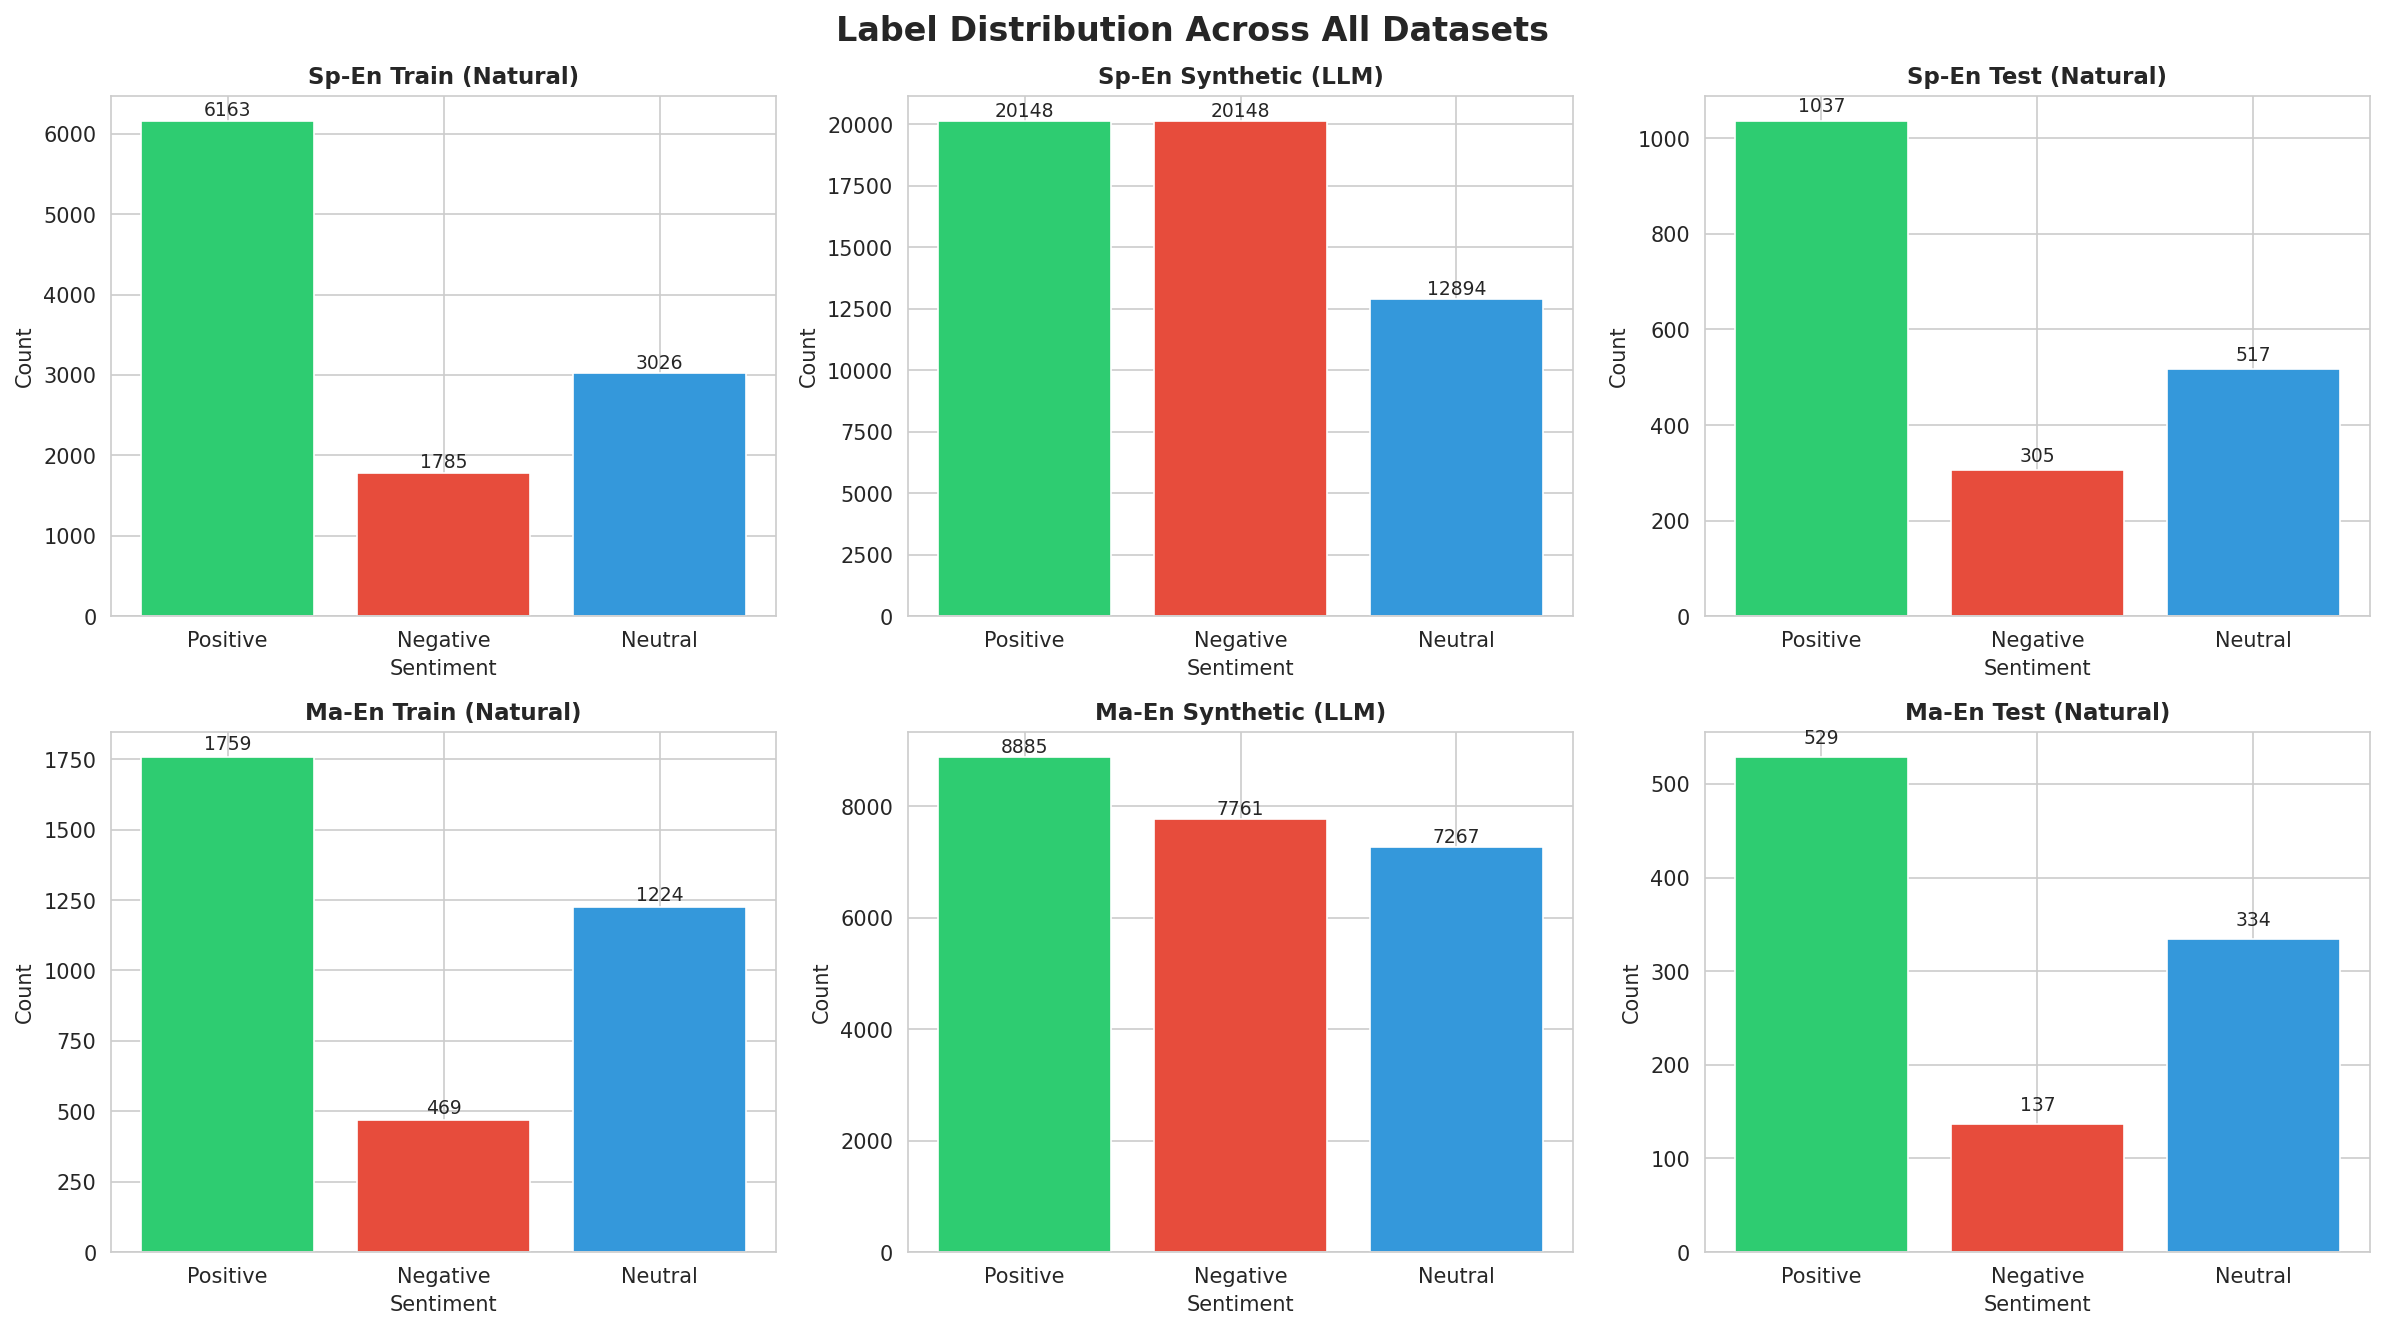

 Plot 1 saved: Label Distributions


In [8]:
# ─── Plot 1: Label distribution for all datasets ───
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Label Distribution Across All Datasets", fontsize=16, fontweight='bold')

datasets_info = [
    (sp_train,    "Sp-En Train (Natural)",    axes[0,0]),
    (sp_syn_llm,  "Sp-En Synthetic (LLM)",    axes[0,1]),
    (sp_test,     "Sp-En Test (Natural)",      axes[0,2]),
    (ma_train,    "Ma-En Train (Natural)",     axes[1,0]),
    (ma_syn_llm,  "Ma-En Synthetic (LLM)",     axes[1,1]),
    (ma_test,     "Ma-En Test (Natural)",      axes[1,2]),
]

colors = ["#2ecc71", "#e74c3c", "#3498db"]

for df, title, ax in datasets_info:
    counts = df['label'].value_counts().reindex(["Positive", "Negative", "Neutral"], fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Count")
    ax.set_xlabel("Sentiment")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plot1_label_distributions.png", bbox_inches='tight')
plt.show()
print(" Plot 1 saved: Label Distributions")

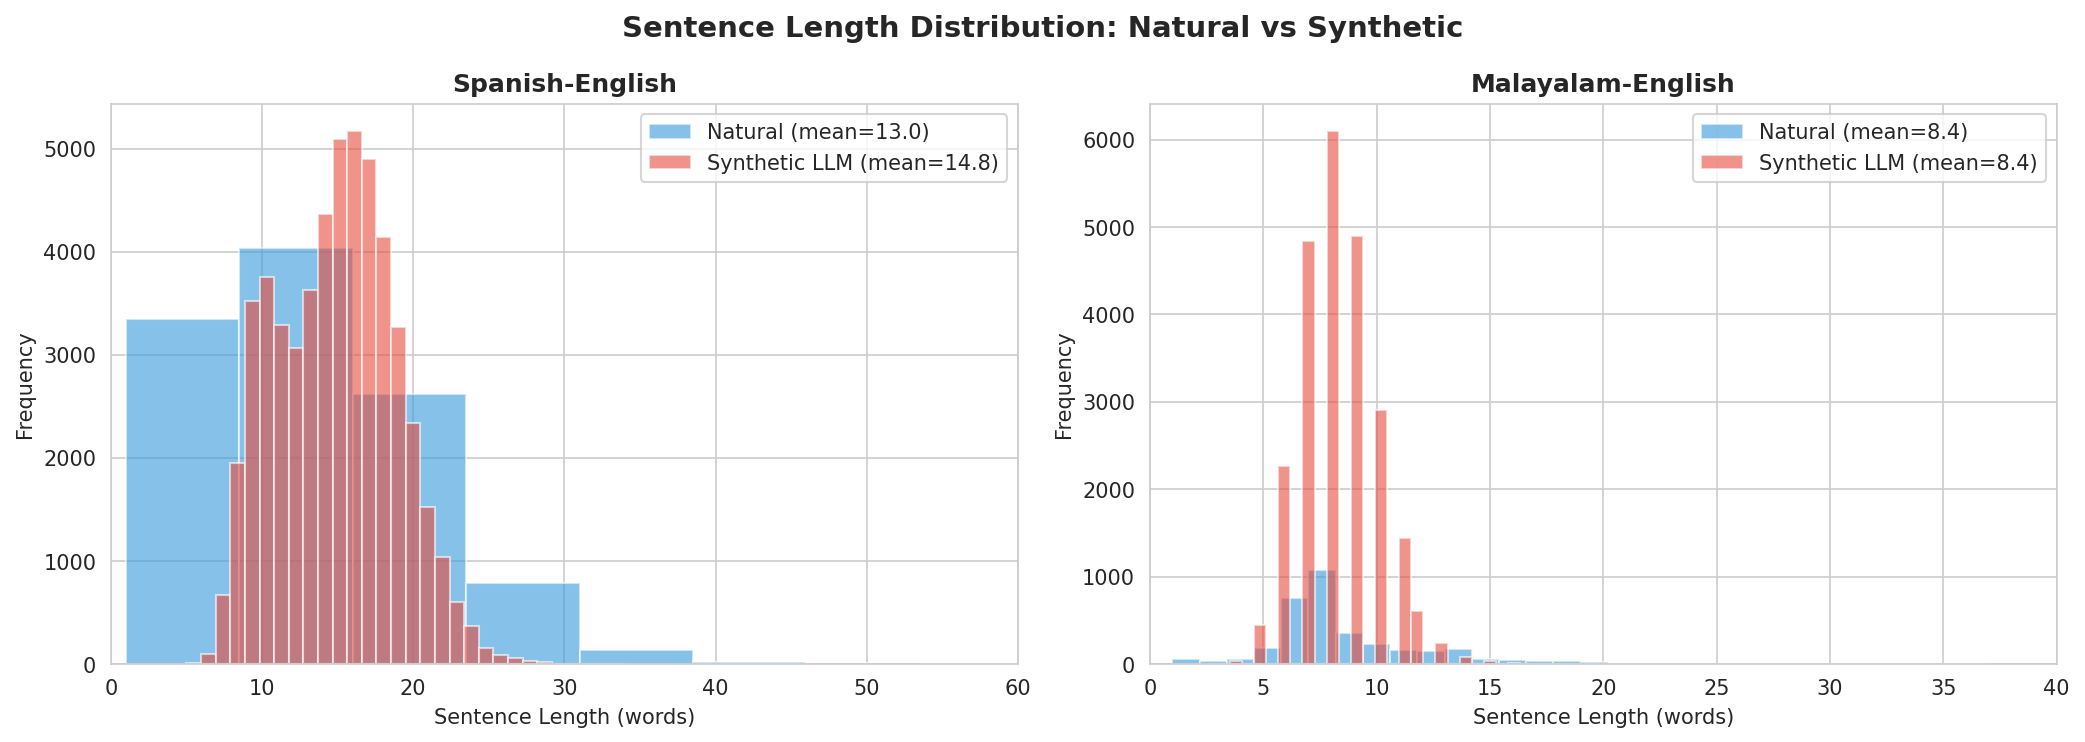

 Plot 2 saved: Sentence Length Distributions


In [9]:
# ─── Plot 2: Sentence length distribution ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sentence Length Distribution: Natural vs Synthetic", fontsize=14, fontweight='bold')

# Spanish-English
sp_nat_lens = sp_train['text'].apply(lambda x: len(x.split()))
sp_syn_lens = sp_syn_llm['text'].apply(lambda x: len(x.split()))
axes[0].hist(sp_nat_lens, bins=30, alpha=0.6, label=f'Natural (mean={sp_nat_lens.mean():.1f})', color='#3498db')
axes[0].hist(sp_syn_lens, bins=30, alpha=0.6, label=f'Synthetic LLM (mean={sp_syn_lens.mean():.1f})', color='#e74c3c')
axes[0].set_title("Spanish-English", fontweight='bold')
axes[0].set_xlabel("Sentence Length (words)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].set_xlim(0, 60)

# Malayalam-English
ma_nat_lens = ma_train['text'].apply(lambda x: len(x.split()))
ma_syn_lens = ma_syn_llm['text'].apply(lambda x: len(x.split()))
axes[1].hist(ma_nat_lens, bins=30, alpha=0.6, label=f'Natural (mean={ma_nat_lens.mean():.1f})', color='#3498db')
axes[1].hist(ma_syn_lens, bins=30, alpha=0.6, label=f'Synthetic LLM (mean={ma_syn_lens.mean():.1f})', color='#e74c3c')
axes[1].set_title("Malayalam-English", fontweight='bold')
axes[1].set_xlabel("Sentence Length (words)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].set_xlim(0, 40)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plot2_sentence_lengths.png", bbox_inches='tight')
plt.show()
print(" Plot 2 saved: Sentence Length Distributions")

In [10]:
# ─── DEBUG: Check preprocessed data looks correct before training ───
# Run this cell to verify labels loaded correctly. If label_id has values
# other than 0/1/2, or if any column is missing, fix preprocess_df() first.

print('=== SPANISH-ENGLISH TRAIN ===')
print(sp_train.head(3))
print('Columns:', sp_train.columns.tolist())
print('Label dist:', sp_train['label'].value_counts().to_dict())
print('label_id unique:', sorted(sp_train['label_id'].unique()))
print('Any NaN in label_id?', sp_train['label_id'].isna().sum())

print('\n=== MALAYALAM-ENGLISH TRAIN ===')
print(ma_train.head(3))
print('Label dist:', ma_train['label'].value_counts().to_dict())
print('label_id unique:', sorted(ma_train['label_id'].unique()))
print('Any NaN in label_id?', ma_train['label_id'].isna().sum())

print('\n=== SAMPLE CLEAN TEXT ===')
print(sp_train['text'].iloc[0])
print(ma_train['text'].iloc[0])

print('\n[If label_id shows only 0,1,2 and no NaN => data is ready]')


=== SPANISH-ENGLISH TRAIN ===
                                                text     label  label_id
0  esto sí que es más que un Goal smirking face s...  Positive         0
1                                My legs are so sore  Negative         1
2  El es síguelo para que sepas donde estará hoy ...   Neutral         2
Columns: ['text', 'label', 'label_id']
Label dist: {'Positive': 6163, 'Neutral': 3026, 'Negative': 1785}
label_id unique: [np.int64(0), np.int64(1), np.int64(2)]
Any NaN in label_id? 0

=== MALAYALAM-ENGLISH TRAIN ===
                                                text     label  label_id
0  Padam pottum... Charithram akanamenkil marakka...  Negative         1
1  ikka dlg delivery oru rakshayumilla ... love u...  Positive         0
2  megastar back in action !!!!!!! bellary rajaya...  Positive         0
Label dist: {'Positive': 1759, 'Neutral': 1224, 'Negative': 469}
label_id unique: [np.int64(0), np.int64(1), np.int64(2)]
Any NaN in label_id? 0

=== SAMPLE CLEAN TEXT 

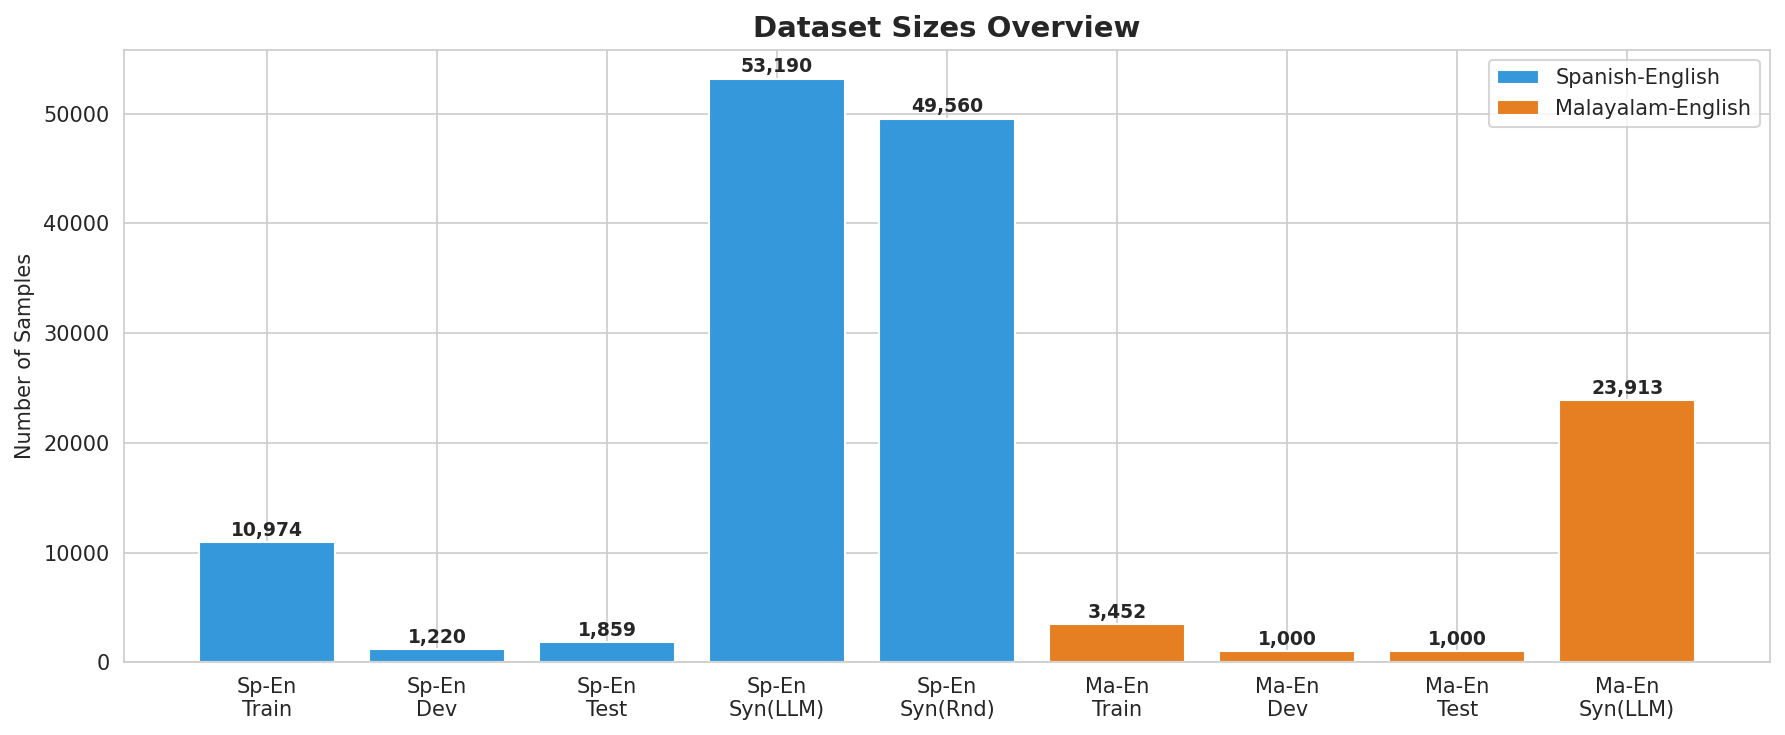

 Plot 3 saved: Dataset Sizes


In [11]:
# ─── Plot 3: Dataset size comparison ───
fig, ax = plt.subplots(figsize=(12, 5))

dataset_names = [
    "Sp-En\nTrain", "Sp-En\nDev", "Sp-En\nTest",
    "Sp-En\nSyn(LLM)", "Sp-En\nSyn(Rnd)",
    "Ma-En\nTrain", "Ma-En\nDev", "Ma-En\nTest", "Ma-En\nSyn(LLM)"
]
dataset_sizes = [
    len(sp_train), len(sp_dev), len(sp_test),
    len(sp_syn_llm), len(sp_syn_rnd),
    len(ma_train), len(ma_dev), len(ma_test), len(ma_syn_llm)
]
colors_bar = ['#3498db']*5 + ['#e67e22']*4

bars = ax.bar(dataset_names, dataset_sizes, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, dataset_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Dataset Sizes Overview", fontsize=14, fontweight='bold')
ax.set_ylabel("Number of Samples")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Spanish-English'),
                   Patch(facecolor='#e67e22', label='Malayalam-English')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plot3_dataset_sizes.png", bbox_inches='tight')
plt.show()
print(" Plot 3 saved: Dataset Sizes")

---
# SECTION 5: Model Setup (mBERT & XLM-T)
---
- **mBERT**: `bert-base-multilingual-cased` — pre-trained on 104 languages
- **XLM-T**: `cardiffnlp/twitter-xlm-roberta-base` — pre-trained on multilingual tweets

Both from HuggingFace. We add a classification head for 3-class (Positive/Negative/Neutral) sentiment.

In [12]:
# ─── Model name mapping ───
MODEL_NAMES = {
    "mBERT": "bert-base-multilingual-cased",
    "XLM-T": "cardiffnlp/twitter-xlm-roberta-base"
}

NUM_LABELS = 3  # Positive, Negative, Neutral
MAX_SEQ_LEN = 40   # Exactly as specified in the paper
BATCH_SIZE  = 32   # Exactly as specified in the paper

print(" Model configuration:")
print(f"   Models     : {list(MODEL_NAMES.keys())}")
print(f"   Labels     : {NUM_LABELS} (Positive / Negative / Neutral)")
print(f"   Max Seq Len: {MAX_SEQ_LEN} tokens")
print(f"   Batch Size : {BATCH_SIZE}")

 Model configuration:
   Models     : ['mBERT', 'XLM-T']
   Labels     : 3 (Positive / Negative / Neutral)
   Max Seq Len: 40 tokens
   Batch Size : 32


In [13]:
# ─── PyTorch Dataset class ───
class SentimentDataset(Dataset):
    """
    Custom dataset class that tokenizes text and returns
    input_ids, attention_mask, and label tensors.
    """
    def __init__(self, dataframe, tokenizer, max_len=MAX_SEQ_LEN):
        self.texts  = dataframe['text'].tolist()
        self.labels = dataframe['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

def build_loader(df, tokenizer, batch_size=BATCH_SIZE, shuffle=True):
    """Build a DataLoader from a dataframe."""
    dataset = SentimentDataset(df, tokenizer)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2)

print(" Dataset class defined")

 Dataset class defined


---
# SECTION 6: Training & Evaluation Functions
---
Implements:
- `train_one_epoch()` — one epoch of training
- `evaluate()` — weighted F1 evaluation
- `run_standard_training()` — single stage fine-tuning
- `run_gradual_finetuning()` — 5-stage gradual fine-tuning (paper's method for Spanish-English)

In [14]:
# ─── Hyperparameters (exactly from paper Appendix B.2) ───
LEARNING_RATE  = 5e-5
WEIGHT_DECAY   = 0.01
EPSILON        = 1e-8
NUM_EPOCHS     = 3   # 3 epochs per stage (as per paper)

# Gradual fine-tuning: synthetic data sizes per stage (paper Table in Appendix B.2)
GRADUAL_STAGES_LR = [1e-6, 2e-6, 2e-6, 4e-6, 2e-6]  # learning rates per stage
GRADUAL_SYN_SIZES = [50000, 25000, 15000, 5000, 0]    # synthetic data size per stage

def train_one_epoch(model, loader, optimizer, scheduler, device):
    """Train model for one epoch. Returns average loss."""
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    return total_loss / len(loader)

def evaluate(model, loader, device):
    """Evaluate model. Returns weighted F1 score, all predictions, all true labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    return f1, all_preds, all_labels

print(" Training functions defined")

 Training functions defined


In [15]:
def safe_classification_report(test_labels, test_preds):
    """
    Safe wrapper for classification_report.
    Always passes labels=[0,1,2] explicitly to avoid the
    'Number of classes does not match target_names' error
    when a class is never predicted.
    """
    print(classification_report(
        test_labels, test_preds,
        labels=[0, 1, 2],
        target_names=["Positive", "Negative", "Neutral"],
        zero_division=0
    ))


def run_standard_training(model_name, train_df, dev_df, test_df,
                           experiment_name, num_epochs=NUM_EPOCHS,
                           lr=LEARNING_RATE):
    """
    Standard single-stage fine-tuning.
    Used for: Malayalam-English experiments and baselines.
    Returns: test_f1, train_losses, dev_f1s, test_preds, test_labels
    """
    print(f"\n{'='*60}")
    print(f"Experiment: {experiment_name}")
    print(f"   Model     : {model_name} | LR: {lr}")
    print(f"   Train size: {len(train_df)}")
    print(f"   Label dist: {train_df['label'].value_counts().to_dict()}")
    print(f"   label_id unique values: {sorted(train_df['label_id'].unique())}")
    print(f"{'='*60}")

    # ── Safety checks ──
    assert len(train_df) > 0, 'Training dataframe is empty!'
    assert 'label_id' in train_df.columns, 'label_id column missing!'
    assert train_df['label_id'].notna().all(), 'NaN values in label_id!'

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAMES[model_name])
    model     = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAMES[model_name], num_labels=NUM_LABELS
    ).to(DEVICE)

    train_loader = build_loader(train_df, tokenizer, shuffle=True)
    dev_loader   = build_loader(dev_df,   tokenizer, shuffle=False)
    test_loader  = build_loader(test_df,  tokenizer, shuffle=False)

    optimizer = AdamW(model.parameters(), lr=lr,
                      weight_decay=WEIGHT_DECAY, eps=EPSILON)
    total_steps = len(train_loader) * num_epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    train_losses, dev_f1s = [], []

    for epoch in range(1, num_epochs + 1):
        loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        dev_f1, _, _ = evaluate(model, dev_loader, DEVICE)
        train_losses.append(loss)
        dev_f1s.append(dev_f1)
        print(f"   Epoch {epoch}/{num_epochs} | Loss: {loss:.4f} | Dev F1: {dev_f1:.4f}")

    test_f1, test_preds, test_labels = evaluate(model, test_loader, DEVICE)
    print(f"\n   TEST F1: {test_f1:.4f}")
    print(f"   Unique predicted classes: {sorted(set(test_preds))}")
    safe_classification_report(test_labels, test_preds)

    del model
    torch.cuda.empty_cache()

    return test_f1, train_losses, dev_f1s, test_preds, test_labels

def run_gradual_finetuning(model_name, natural_train_df, synthetic_df,
                            dev_df, test_df, experiment_name):
    """
    5-stage Gradual Fine-Tuning as described in paper Section 3.3.
    Stage 1: natural + 50k synthetic
    Stage 2: natural + 25k synthetic
    Stage 3: natural + 15k synthetic
    Stage 4: natural + 5k synthetic
    Stage 5: natural only

    Used for: Spanish-English natural + LLM synthetic experiment.
    Returns: test_f1, all_losses, all_dev_f1s
    """
    print(f"\n{'='*60}")
    print(f"🔧 Gradual Fine-Tuning: {experiment_name}")
    print(f"   Model: {model_name} | Natural train: {len(natural_train_df)}")
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAMES[model_name])
    model     = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAMES[model_name], num_labels=NUM_LABELS
    ).to(DEVICE)

    dev_loader  = build_loader(dev_df,  tokenizer, shuffle=False)
    test_loader = build_loader(test_df, tokenizer, shuffle=False)

    all_losses, all_dev_f1s = [], []

    for stage_idx, (syn_size, stage_lr) in enumerate(
        zip(GRADUAL_SYN_SIZES, GRADUAL_STAGES_LR)
    ):
        print(f"\n  📌 Stage {stage_idx+1}/5 | Synthetic size: {syn_size} | LR: {stage_lr}")

        # Build combined dataset for this stage
        if syn_size > 0:
            syn_sample = synthetic_df.sample(
                n=min(syn_size, len(synthetic_df)),
                random_state=SEED
            )
            stage_df = pd.concat([natural_train_df, syn_sample], ignore_index=True)
        else:
            stage_df = natural_train_df.copy()

        train_loader = build_loader(stage_df, tokenizer, shuffle=True)

        optimizer = AdamW(model.parameters(), lr=stage_lr,
                          weight_decay=WEIGHT_DECAY, eps=EPSILON)
        total_steps = len(train_loader) * NUM_EPOCHS
        scheduler   = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps
        )

        for epoch in range(1, NUM_EPOCHS + 1):
            loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
            dev_f1, _, _ = evaluate(model, dev_loader, DEVICE)
            all_losses.append(loss)
            all_dev_f1s.append(dev_f1)
            print(f"     Epoch {epoch} | Loss: {loss:.4f} | Dev F1: {dev_f1:.4f}")

    test_f1, test_preds, test_labels = evaluate(model, test_loader, DEVICE)
    print(f"\n   FINAL TEST F1: {test_f1:.4f}")
    safe_classification_report(test_labels, test_preds)

    del model
    torch.cuda.empty_cache()

    return test_f1, all_losses, all_dev_f1s, test_preds, test_labels

print(" All training functions defined")

 All training functions defined


---
# SECTION 7: Experiment 1 — Spanish-English (Full 12k Natural Data)
---
Reproduces Table 3 of the paper for full Spanish-English dataset.  
Runs the following configurations:  
1. XLM-T: Natural data only (our baseline)  
2. XLM-T: Synthetic LLM only  
3. XLM-T: Natural + Synthetic LLM (Gradual Fine-Tuning) ← paper's best result  
4. XLM-T: Natural + Synthetic Random Translation  
5. mBERT: Natural data only (dataset baseline)

In [16]:
# ─── Storage for all results ───
# We store results as: results[experiment_name] = {f1, losses, dev_f1s, preds, labels}
results = {}

print(" Starting Experiment 1: Spanish-English Full 12k")
print("This will run 5 training configurations. Estimated time: ~60-90 min on P100")

 Starting Experiment 1: Spanish-English Full 12k
This will run 5 training configurations. Estimated time: ~60-90 min on P100


In [17]:
# ─── Exp 1.1: mBERT on Natural data only (dataset baseline) ───
f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="mBERT",
    train_df=sp_train,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En | mBERT | Natural Only (Dataset Baseline)"
)
results["sp_mbert_natural"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                "preds": preds, "labels": labels, "paper_f1": 0.564}


Experiment: Sp-En | mBERT | Natural Only (Dataset Baseline)
   Model     : mBERT | LR: 5e-05
   Train size: 10974
   Label dist: {'Positive': 6163, 'Neutral': 3026, 'Negative': 1785}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Epoch 1/3 | Loss: 0.9563 | Dev F1: 0.4554
   Epoch 2/3 | Loss: 0.8775 | Dev F1: 0.5225
   Epoch 3/3 | Loss: 0.7627 | Dev F1: 0.5543

   TEST F1: 0.5445
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.64      0.82      0.72      1037
    Negative       0.49      0.43      0.46       305
     Neutral       0.36      0.19      0.25       517

    accuracy                           0.58      1859
   macro avg       0.50      0.48      0.47      1859
weighted avg       0.54      0.58      0.54      1859



In [18]:
# ─── Exp 1.2: XLM-T on Natural data only (our baseline) ───
f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="XLM-T",
    train_df=sp_train,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En | XLM-T | Natural Only (Our Baseline)"
)
results["sp_xlmt_natural"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                               "preds": preds, "labels": labels, "paper_f1": 0.588}


Experiment: Sp-En | XLM-T | Natural Only (Our Baseline)
   Model     : XLM-T | LR: 5e-05
   Train size: 10974
   Label dist: {'Positive': 6163, 'Neutral': 3026, 'Negative': 1785}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


config.json:   0%|          | 0.00/652 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

   Epoch 1/3 | Loss: 0.9173 | Dev F1: 0.5111
   Epoch 2/3 | Loss: 0.7896 | Dev F1: 0.5557
   Epoch 3/3 | Loss: 0.6522 | Dev F1: 0.5923

   TEST F1: 0.5824
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.67      0.80      0.73      1037
    Negative       0.54      0.54      0.54       305
     Neutral       0.42      0.25      0.32       517

    accuracy                           0.61      1859
   macro avg       0.54      0.53      0.53      1859
weighted avg       0.58      0.61      0.58      1859



In [19]:
# ─── Exp 1.3: XLM-T on Synthetic LLM data only ───
# Sample 50k from the synthetic data (as in paper)
sp_syn_50k = sp_syn_llm.sample(n=min(50000, len(sp_syn_llm)), random_state=SEED)

f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="XLM-T",
    train_df=sp_syn_50k,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En | XLM-T | Synthetic LLM Only"
)
results["sp_xlmt_syn_only"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                "preds": preds, "labels": labels, "paper_f1": 0.544}


Experiment: Sp-En | XLM-T | Synthetic LLM Only
   Model     : XLM-T | LR: 5e-05
   Train size: 50000
   Label dist: {'Positive': 18982, 'Negative': 18898, 'Neutral': 12120}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr

   Epoch 1/3 | Loss: 0.4085 | Dev F1: 0.5332
   Epoch 2/3 | Loss: 0.2014 | Dev F1: 0.5365
   Epoch 3/3 | Loss: 0.0917 | Dev F1: 0.5547

   TEST F1: 0.5306
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.69      0.58      0.63      1037
    Negative       0.45      0.56      0.50       305
     Neutral       0.32      0.38      0.34       517

    accuracy                           0.52      1859
   macro avg       0.49      0.51      0.49      1859
weighted avg       0.55      0.52      0.53      1859



In [20]:
# ─── Exp 1.4: XLM-T Natural + Synthetic LLM — Gradual Fine-Tuning ← PAPER'S BEST ───
f1, losses, dev_f1s, preds, labels = run_gradual_finetuning(
    model_name="XLM-T",
    natural_train_df=sp_train,
    synthetic_df=sp_syn_llm,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En | XLM-T | Natural + LLM Synthetic (Gradual FT)"
)
results["sp_xlmt_gradual"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                               "preds": preds, "labels": labels, "paper_f1": 0.603}


🔧 Gradual Fine-Tuning: Sp-En | XLM-T | Natural + LLM Synthetic (Gradual FT)
   Model: XLM-T | Natural train: 10974


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr


  📌 Stage 1/5 | Synthetic size: 50000 | LR: 1e-06
     Epoch 1 | Loss: 0.7468 | Dev F1: 0.5436
     Epoch 2 | Loss: 0.5009 | Dev F1: 0.5451
     Epoch 3 | Loss: 0.4749 | Dev F1: 0.5475

  📌 Stage 2/5 | Synthetic size: 25000 | LR: 2e-06
     Epoch 1 | Loss: 0.5230 | Dev F1: 0.5513
     Epoch 2 | Loss: 0.4912 | Dev F1: 0.5563
     Epoch 3 | Loss: 0.4741 | Dev F1: 0.5534

  📌 Stage 3/5 | Synthetic size: 15000 | LR: 2e-06
     Epoch 1 | Loss: 0.5304 | Dev F1: 0.5697
     Epoch 2 | Loss: 0.5127 | Dev F1: 0.5621
     Epoch 3 | Loss: 0.4971 | Dev F1: 0.5626

  📌 Stage 4/5 | Synthetic size: 5000 | LR: 4e-06
     Epoch 1 | Loss: 0.6419 | Dev F1: 0.5601
     Epoch 2 | Loss: 0.6135 | Dev F1: 0.5605
     Epoch 3 | Loss: 0.5883 | Dev F1: 0.5682

  📌 Stage 5/5 | Synthetic size: 0 | LR: 2e-06
     Epoch 1 | Loss: 0.7400 | Dev F1: 0.5655
     Epoch 2 | Loss: 0.7247 | Dev F1: 0.5654
     Epoch 3 | Loss: 0.7082 | Dev F1: 0.5667

   FINAL TEST F1: 0.5582
              precision    recall  f1-score   sup

In [21]:
# ─── Exp 1.5: XLM-T Natural + Random Translation (comparison baseline) ───
sp_rnd_combined = pd.concat([sp_train, sp_syn_rnd.sample(
    n=min(50000, len(sp_syn_rnd)), random_state=SEED)], ignore_index=True)

f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="XLM-T",
    train_df=sp_rnd_combined,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En | XLM-T | Natural + Random Translation"
)
results["sp_xlmt_random"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                              "preds": preds, "labels": labels, "paper_f1": 0.563}


Experiment: Sp-En | XLM-T | Natural + Random Translation
   Model     : XLM-T | LR: 5e-05
   Train size: 60534
   Label dist: {'Neutral': 25208, 'Positive': 19992, 'Negative': 15334}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr

   Epoch 1/3 | Loss: 0.5473 | Dev F1: 0.5375
   Epoch 2/3 | Loss: 0.3585 | Dev F1: 0.5342
   Epoch 3/3 | Loss: 0.2375 | Dev F1: 0.5695

   TEST F1: 0.5812
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.67      0.82      0.74      1037
    Negative       0.56      0.52      0.54       305
     Neutral       0.39      0.24      0.30       517

    accuracy                           0.61      1859
   macro avg       0.54      0.53      0.52      1859
weighted avg       0.57      0.61      0.58      1859



---
# SECTION 8: Experiment 2 — Spanish-English Subset (3k Low-Resource Setup)
---
Reproduces the low-resource setup from Table 4 of the paper.  
Natural training data is reduced to 3,000 samples.  
This is where the paper claims the biggest improvement: **+9.32% F1** with LLM augmentation.

In [22]:
print(" Starting Experiment 2: Spanish-English Subset 3k")

# ─── Create 3k subset of natural training data ───
sp_train_3k = sp_train.sample(n=3000, random_state=SEED).reset_index(drop=True)
print(f"   Subset size: {len(sp_train_3k)} samples")
print(f"   Label dist: {sp_train_3k['label'].value_counts().to_dict()}")

 Starting Experiment 2: Spanish-English Subset 3k
   Subset size: 3000 samples
   Label dist: {'Positive': 1686, 'Neutral': 820, 'Negative': 494}


In [23]:
# ─── Exp 2.1: XLM-T on 3k Natural only (low-resource baseline) ───
f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="XLM-T",
    train_df=sp_train_3k,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En 3k | XLM-T | Natural Only (Low-Resource Baseline)"
)
results["sp3k_xlmt_natural"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                 "preds": preds, "labels": labels, "paper_f1": 0.547}


Experiment: Sp-En 3k | XLM-T | Natural Only (Low-Resource Baseline)
   Model     : XLM-T | LR: 5e-05
   Train size: 3000
   Label dist: {'Positive': 1686, 'Neutral': 820, 'Negative': 494}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr

   Epoch 1/3 | Loss: 0.9565 | Dev F1: 0.4995
   Epoch 2/3 | Loss: 0.8124 | Dev F1: 0.5578
   Epoch 3/3 | Loss: 0.6368 | Dev F1: 0.5719

   TEST F1: 0.5669
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.66      0.81      0.73      1037
    Negative       0.51      0.48      0.50       305
     Neutral       0.40      0.22      0.29       517

    accuracy                           0.59      1859
   macro avg       0.52      0.51      0.50      1859
weighted avg       0.56      0.59      0.57      1859



In [24]:
# ─── Exp 2.2: XLM-T 3k Natural + LLM Synthetic — Gradual Fine-Tuning ← KEY RESULT ───
f1, losses, dev_f1s, preds, labels = run_gradual_finetuning(
    model_name="XLM-T",
    natural_train_df=sp_train_3k,
    synthetic_df=sp_syn_llm,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En 3k | XLM-T | Natural + LLM Synthetic — KEY RESULT (+9.32%)"
)
results["sp3k_xlmt_gradual"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                 "preds": preds, "labels": labels, "paper_f1": 0.598}


🔧 Gradual Fine-Tuning: Sp-En 3k | XLM-T | Natural + LLM Synthetic — KEY RESULT (+9.32%)
   Model: XLM-T | Natural train: 3000


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr


  📌 Stage 1/5 | Synthetic size: 50000 | LR: 1e-06
     Epoch 1 | Loss: 0.7668 | Dev F1: 0.5446
     Epoch 2 | Loss: 0.4573 | Dev F1: 0.5428
     Epoch 3 | Loss: 0.4234 | Dev F1: 0.5409

  📌 Stage 2/5 | Synthetic size: 25000 | LR: 2e-06
     Epoch 1 | Loss: 0.4348 | Dev F1: 0.5522
     Epoch 2 | Loss: 0.3980 | Dev F1: 0.5435
     Epoch 3 | Loss: 0.3804 | Dev F1: 0.5468

  📌 Stage 3/5 | Synthetic size: 15000 | LR: 2e-06
     Epoch 1 | Loss: 0.4046 | Dev F1: 0.5564
     Epoch 2 | Loss: 0.3833 | Dev F1: 0.5466
     Epoch 3 | Loss: 0.3693 | Dev F1: 0.5502

  📌 Stage 4/5 | Synthetic size: 5000 | LR: 4e-06
     Epoch 1 | Loss: 0.4900 | Dev F1: 0.5566
     Epoch 2 | Loss: 0.4555 | Dev F1: 0.5503
     Epoch 3 | Loss: 0.4262 | Dev F1: 0.5561

  📌 Stage 5/5 | Synthetic size: 0 | LR: 2e-06
     Epoch 1 | Loss: 0.7277 | Dev F1: 0.5576
     Epoch 2 | Loss: 0.7078 | Dev F1: 0.5575
     Epoch 3 | Loss: 0.6905 | Dev F1: 0.5569

   FINAL TEST F1: 0.5531
              precision    recall  f1-score   sup

In [25]:
# ─── Exp 2.3: mBERT on 3k Natural only ───
f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="mBERT",
    train_df=sp_train_3k,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En 3k | mBERT | Natural Only"
)
results["sp3k_mbert_natural"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                  "preds": preds, "labels": labels, "paper_f1": 0.487}


Experiment: Sp-En 3k | mBERT | Natural Only
   Model     : mBERT | LR: 5e-05
   Train size: 3000
   Label dist: {'Positive': 1686, 'Neutral': 820, 'Negative': 494}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Epoch 1/3 | Loss: 0.9746 | Dev F1: 0.4374
   Epoch 2/3 | Loss: 0.8826 | Dev F1: 0.5033
   Epoch 3/3 | Loss: 0.7390 | Dev F1: 0.5399

   TEST F1: 0.5253
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.62      0.85      0.72      1037
    Negative       0.46      0.35      0.40       305
     Neutral       0.36      0.15      0.22       517

    accuracy                           0.57      1859
   macro avg       0.48      0.45      0.44      1859
weighted avg       0.52      0.57      0.53      1859



In [26]:
# ─── Exp 2.4: mBERT 3k Natural + LLM Synthetic ───
sp3k_mbert_combined = pd.concat([sp_train_3k, sp_syn_llm.sample(
    n=min(50000, len(sp_syn_llm)), random_state=SEED)], ignore_index=True)

f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="mBERT",
    train_df=sp3k_mbert_combined,
    dev_df=sp_dev,
    test_df=sp_test,
    experiment_name="Sp-En 3k | mBERT | Natural + LLM Synthetic"
)
results["sp3k_mbert_gradual"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                  "preds": preds, "labels": labels, "paper_f1": 0.526}


Experiment: Sp-En 3k | mBERT | Natural + LLM Synthetic
   Model     : mBERT | LR: 5e-05
   Train size: 53000
   Label dist: {'Positive': 20668, 'Negative': 19392, 'Neutral': 12940}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Epoch 1/3 | Loss: 0.5379 | Dev F1: 0.5204
   Epoch 2/3 | Loss: 0.3139 | Dev F1: 0.5413
   Epoch 3/3 | Loss: 0.1652 | Dev F1: 0.5559

   TEST F1: 0.5294
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.63      0.74      0.68      1037
    Negative       0.48      0.38      0.43       305
     Neutral       0.32      0.26      0.29       517

    accuracy                           0.54      1859
   macro avg       0.48      0.46      0.46      1859
weighted avg       0.52      0.54      0.53      1859



---
# SECTION 9: Experiment 3 — Malayalam-English (3.5k)
---
Reproduces Table 3 and Table 4 Malayalam-English results.  
Key finding from paper: XLM-T already achieves high F1 on natural data,  
and synthetic data actually **hurts** XLM-T but slightly helps mBERT.

In [27]:
print(" Starting Experiment 3: Malayalam-English")

 Starting Experiment 3: Malayalam-English


In [28]:
# ─── Exp 3.1: mBERT on Natural data only ───
f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="mBERT",
    train_df=ma_train,
    dev_df=ma_dev,
    test_df=ma_test,
    experiment_name="Ma-En | mBERT | Natural Only"
)
results["ma_mbert_natural"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                "preds": preds, "labels": labels, "paper_f1": 0.750}


Experiment: Ma-En | mBERT | Natural Only
   Model     : mBERT | LR: 5e-05
   Train size: 3452
   Label dist: {'Positive': 1759, 'Neutral': 1224, 'Negative': 469}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Epoch 1/3 | Loss: 0.8650 | Dev F1: 0.6676
   Epoch 2/3 | Loss: 0.6313 | Dev F1: 0.7250
   Epoch 3/3 | Loss: 0.4349 | Dev F1: 0.7515

   TEST F1: 0.7333
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.77      0.84      0.80       529
    Negative       0.65      0.52      0.58       137
     Neutral       0.71      0.66      0.68       334

    accuracy                           0.74      1000
   macro avg       0.71      0.67      0.69      1000
weighted avg       0.73      0.74      0.73      1000



In [29]:
# ─── Exp 3.2: XLM-T on Natural data only (should be best for Malayalam) ───
f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="XLM-T",
    train_df=ma_train,
    dev_df=ma_dev,
    test_df=ma_test,
    experiment_name="Ma-En | XLM-T | Natural Only (Expected Best)"
)
results["ma_xlmt_natural"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                               "preds": preds, "labels": labels, "paper_f1": 0.843}


Experiment: Ma-En | XLM-T | Natural Only (Expected Best)
   Model     : XLM-T | LR: 5e-05
   Train size: 3452
   Label dist: {'Positive': 1759, 'Neutral': 1224, 'Negative': 469}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr

   Epoch 1/3 | Loss: 0.8716 | Dev F1: 0.6822
   Epoch 2/3 | Loss: 0.6136 | Dev F1: 0.7535
   Epoch 3/3 | Loss: 0.4366 | Dev F1: 0.7590

   TEST F1: 0.7336
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.79      0.82      0.81       529
    Negative       0.60      0.45      0.51       137
     Neutral       0.69      0.72      0.71       334

    accuracy                           0.74      1000
   macro avg       0.69      0.66      0.68      1000
weighted avg       0.73      0.74      0.73      1000



In [30]:
# ─── Exp 3.3: XLM-T on Natural + Synthetic LLM (should decrease — paper's finding) ───
ma_combined = pd.concat([ma_train, ma_syn_llm.sample(
    n=min(15000, len(ma_syn_llm)), random_state=SEED)], ignore_index=True)

f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="XLM-T",
    train_df=ma_combined,
    dev_df=ma_dev,
    test_df=ma_test,
    experiment_name="Ma-En | XLM-T | Natural + Synthetic LLM (Expected Decrease)"
)
results["ma_xlmt_combined"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                "preds": preds, "labels": labels, "paper_f1": 0.763}


Experiment: Ma-En | XLM-T | Natural + Synthetic LLM (Expected Decrease)
   Model     : XLM-T | LR: 5e-05
   Train size: 18452
   Label dist: {'Positive': 7376, 'Neutral': 5756, 'Negative': 5320}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr

   Epoch 1/3 | Loss: 0.5080 | Dev F1: 0.7277
   Epoch 2/3 | Loss: 0.2840 | Dev F1: 0.7607
   Epoch 3/3 | Loss: 0.1879 | Dev F1: 0.7600

   TEST F1: 0.7438
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.80      0.83      0.82       529
    Negative       0.60      0.54      0.57       137
     Neutral       0.72      0.69      0.70       334

    accuracy                           0.75      1000
   macro avg       0.70      0.69      0.70      1000
weighted avg       0.74      0.75      0.74      1000



In [31]:
# ─── Exp 3.4: mBERT on Natural + Synthetic LLM (should slightly improve) ───
ma_mbert_combined = pd.concat([ma_train, ma_syn_llm.sample(
    n=min(15000, len(ma_syn_llm)), random_state=SEED)], ignore_index=True)

f1, losses, dev_f1s, preds, labels = run_standard_training(
    model_name="mBERT",
    train_df=ma_mbert_combined,
    dev_df=ma_dev,
    test_df=ma_test,
    experiment_name="Ma-En | mBERT | Natural + Synthetic LLM (Slight Improvement)"
)
results["ma_mbert_combined"] = {"f1": f1, "losses": losses, "dev_f1s": dev_f1s,
                                 "preds": preds, "labels": labels, "paper_f1": 0.745}


Experiment: Ma-En | mBERT | Natural + Synthetic LLM (Slight Improvement)
   Model     : mBERT | LR: 5e-05
   Train size: 18452
   Label dist: {'Positive': 7376, 'Neutral': 5756, 'Negative': 5320}
   label_id unique values: [np.int64(0), np.int64(1), np.int64(2)]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Epoch 1/3 | Loss: 0.5364 | Dev F1: 0.6812
   Epoch 2/3 | Loss: 0.3033 | Dev F1: 0.7128
   Epoch 3/3 | Loss: 0.1956 | Dev F1: 0.7406

   TEST F1: 0.7271
   Unique predicted classes: [np.int64(0), np.int64(1), np.int64(2)]
              precision    recall  f1-score   support

    Positive       0.77      0.82      0.79       529
    Negative       0.66      0.55      0.60       137
     Neutral       0.69      0.66      0.67       334

    accuracy                           0.73      1000
   macro avg       0.70      0.68      0.69      1000
weighted avg       0.73      0.73      0.73      1000



---
# SECTION 10: Results Summary + Comparison Tables
---
Compare our reproduced F1 scores against the paper's reported F1 scores.

In [32]:
# ─── Build results comparison table ───
comparison_data = [
    # Experiment Name, Model, Data Setup, Paper F1, Our F1
    ("Sp-En Full", "mBERT",  "Natural Only",         results["sp_mbert_natural"]["paper_f1"],  results["sp_mbert_natural"]["f1"]),
    ("Sp-En Full", "XLM-T",  "Natural Only",         results["sp_xlmt_natural"]["paper_f1"],  results["sp_xlmt_natural"]["f1"]),
    ("Sp-En Full", "XLM-T",  "Synthetic LLM Only",  results["sp_xlmt_syn_only"]["paper_f1"], results["sp_xlmt_syn_only"]["f1"]),
    ("Sp-En Full", "XLM-T",  "Natural + LLM (GFT)", results["sp_xlmt_gradual"]["paper_f1"],  results["sp_xlmt_gradual"]["f1"]),
    ("Sp-En Full", "XLM-T",  "Natural + Random",    results["sp_xlmt_random"]["paper_f1"],   results["sp_xlmt_random"]["f1"]),
    ("Sp-En 3k",   "XLM-T",  "Natural Only",         results["sp3k_xlmt_natural"]["paper_f1"],results["sp3k_xlmt_natural"]["f1"]),
    ("Sp-En 3k",   "XLM-T",  "Natural + LLM (GFT)", results["sp3k_xlmt_gradual"]["paper_f1"],results["sp3k_xlmt_gradual"]["f1"]),
    ("Sp-En 3k",   "mBERT",  "Natural Only",         results["sp3k_mbert_natural"]["paper_f1"],results["sp3k_mbert_natural"]["f1"]),
    ("Sp-En 3k",   "mBERT",  "Natural + LLM",        results["sp3k_mbert_gradual"]["paper_f1"],results["sp3k_mbert_gradual"]["f1"]),
    ("Ma-En",      "mBERT",  "Natural Only",         results["ma_mbert_natural"]["paper_f1"],  results["ma_mbert_natural"]["f1"]),
    ("Ma-En",      "XLM-T",  "Natural Only",         results["ma_xlmt_natural"]["paper_f1"],   results["ma_xlmt_natural"]["f1"]),
    ("Ma-En",      "XLM-T",  "Natural + LLM",        results["ma_xlmt_combined"]["paper_f1"],  results["ma_xlmt_combined"]["f1"]),
    ("Ma-En",      "mBERT",  "Natural + LLM",        results["ma_mbert_combined"]["paper_f1"], results["ma_mbert_combined"]["f1"]),
]

df_compare = pd.DataFrame(comparison_data,
    columns=["Dataset", "Model", "Data Setup", "Paper F1", "Reproduced F1"])
df_compare["Difference"] = (df_compare["Reproduced F1"] - df_compare["Paper F1"]).round(4)
df_compare["Paper F1"]      = df_compare["Paper F1"].round(3)
df_compare["Reproduced F1"] = df_compare["Reproduced F1"].round(3)

print("\n" + "="*75)
print("RESULTS: Paper vs Reproduced F1 Scores")
print("="*75)
print(df_compare.to_string(index=False))

# Save to CSV
df_compare.to_csv(f"{PLOT_DIR}/results_comparison.csv", index=False)
print("\n Results table saved to plots/results_comparison.csv")


RESULTS: Paper vs Reproduced F1 Scores
   Dataset Model          Data Setup  Paper F1  Reproduced F1  Difference
Sp-En Full mBERT        Natural Only     0.564          0.544     -0.0195
Sp-En Full XLM-T        Natural Only     0.588          0.582     -0.0056
Sp-En Full XLM-T  Synthetic LLM Only     0.544          0.531     -0.0134
Sp-En Full XLM-T Natural + LLM (GFT)     0.603          0.558     -0.0448
Sp-En Full XLM-T    Natural + Random     0.563          0.581      0.0182
  Sp-En 3k XLM-T        Natural Only     0.547          0.567      0.0199
  Sp-En 3k XLM-T Natural + LLM (GFT)     0.598          0.553     -0.0449
  Sp-En 3k mBERT        Natural Only     0.487          0.525      0.0383
  Sp-En 3k mBERT       Natural + LLM     0.526          0.529      0.0034
     Ma-En mBERT        Natural Only     0.750          0.733     -0.0167
     Ma-En XLM-T        Natural Only     0.843          0.734     -0.1094
     Ma-En XLM-T       Natural + LLM     0.763          0.744     -0.019

---
# SECTION 11: Training Curves & All Plots
---
All plots are saved to the `./plots/` folder for use in the report.

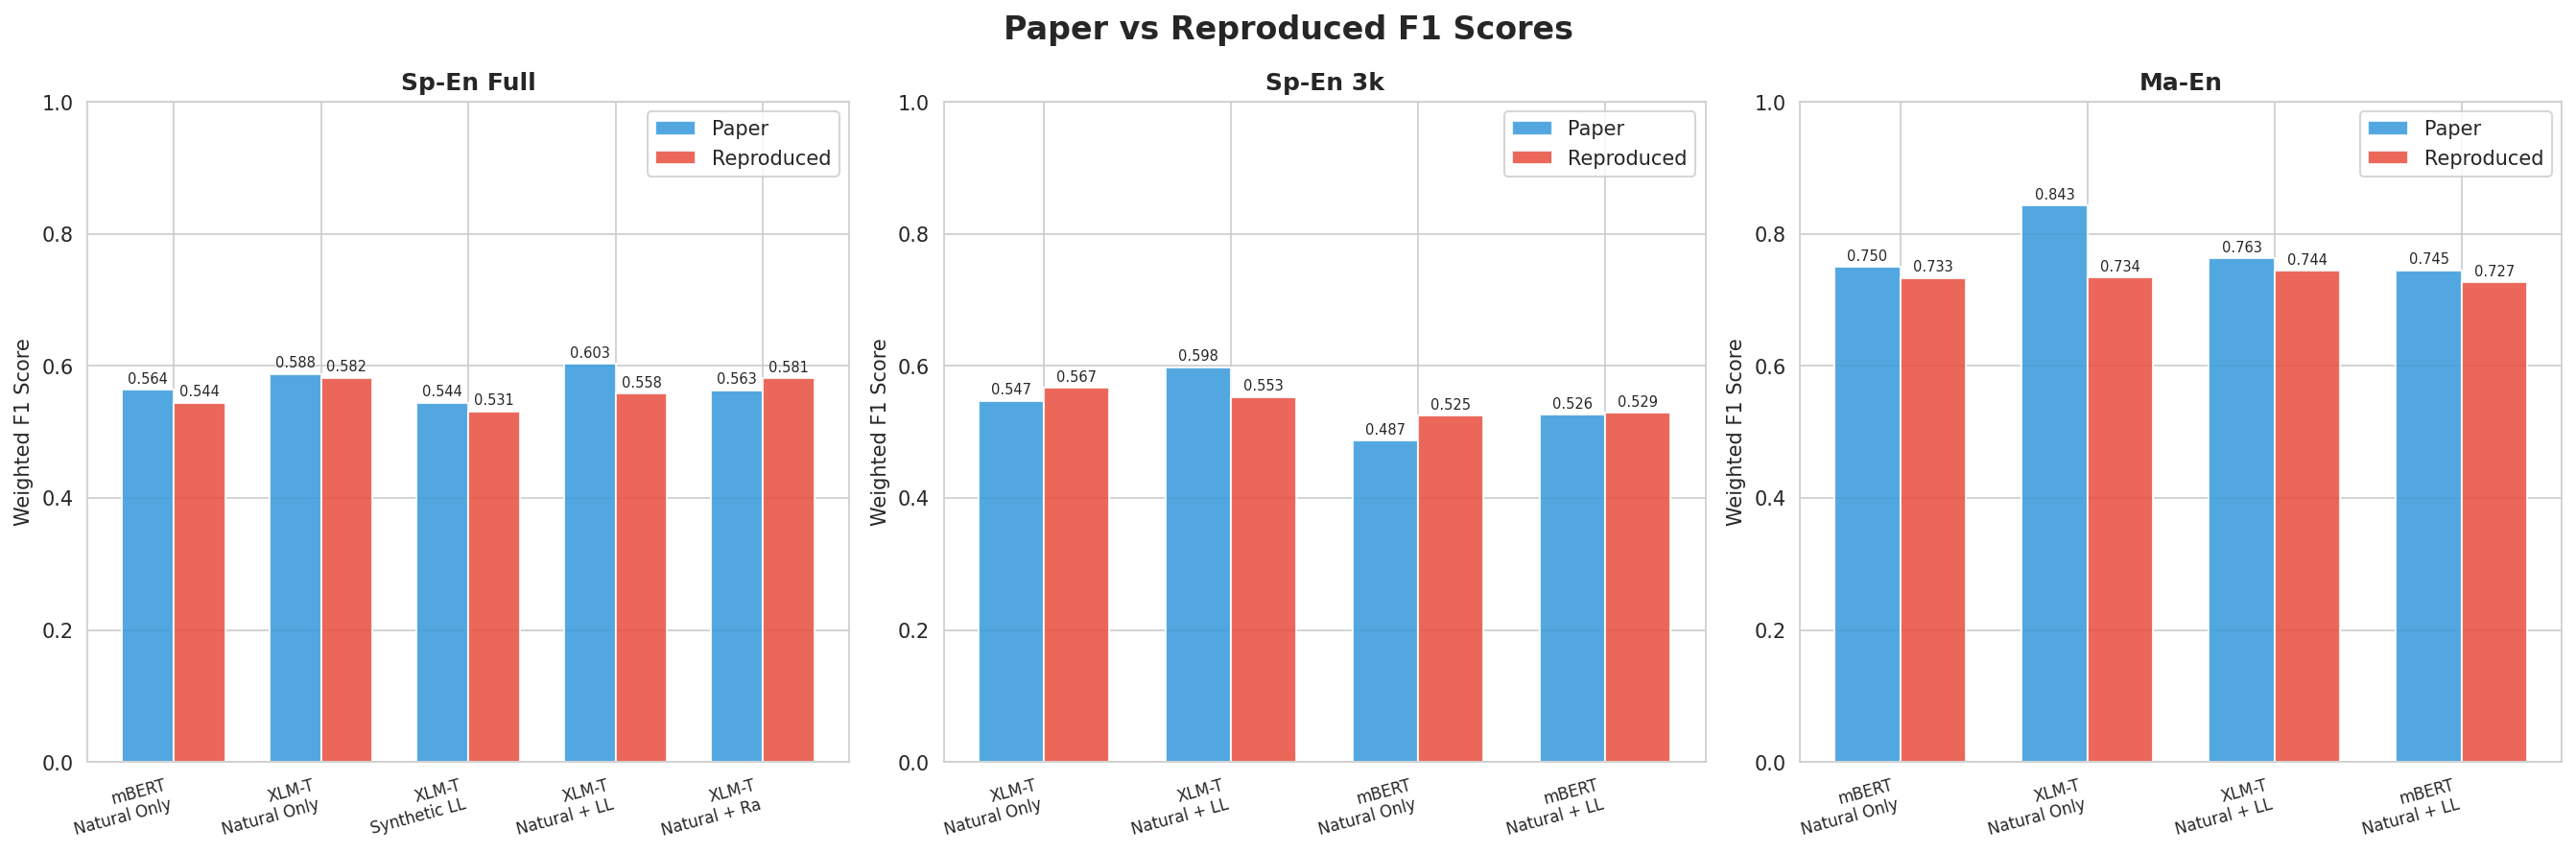

 Plot 4 saved: Paper vs Reproduced Comparison


In [33]:
# ─── Plot 4: Paper vs Reproduced F1 Comparison Bar Chart ───
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Paper vs Reproduced F1 Scores", fontsize=16, fontweight='bold')

subsets = [("Sp-En Full", axes[0]), ("Sp-En 3k", axes[1]), ("Ma-En", axes[2])]

for subset_name, ax in subsets:
    sub = df_compare[df_compare["Dataset"] == subset_name]
    x = np.arange(len(sub))
    width = 0.35
    bars1 = ax.bar(x - width/2, sub["Paper F1"],      width, label="Paper",      color="#3498db", alpha=0.85)
    bars2 = ax.bar(x + width/2, sub["Reproduced F1"], width, label="Reproduced", color="#e74c3c", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{m}\n{d[:12]}" for m, d in zip(sub["Model"], sub["Data Setup"])],
                        fontsize=8, rotation=15, ha='right')
    ax.set_title(subset_name, fontweight='bold')
    ax.set_ylabel("Weighted F1 Score")
    ax.set_ylim(0, 1.0)
    ax.legend()
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha='center', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plot4_paper_vs_reproduced.png", bbox_inches='tight')
plt.show()
print(" Plot 4 saved: Paper vs Reproduced Comparison")

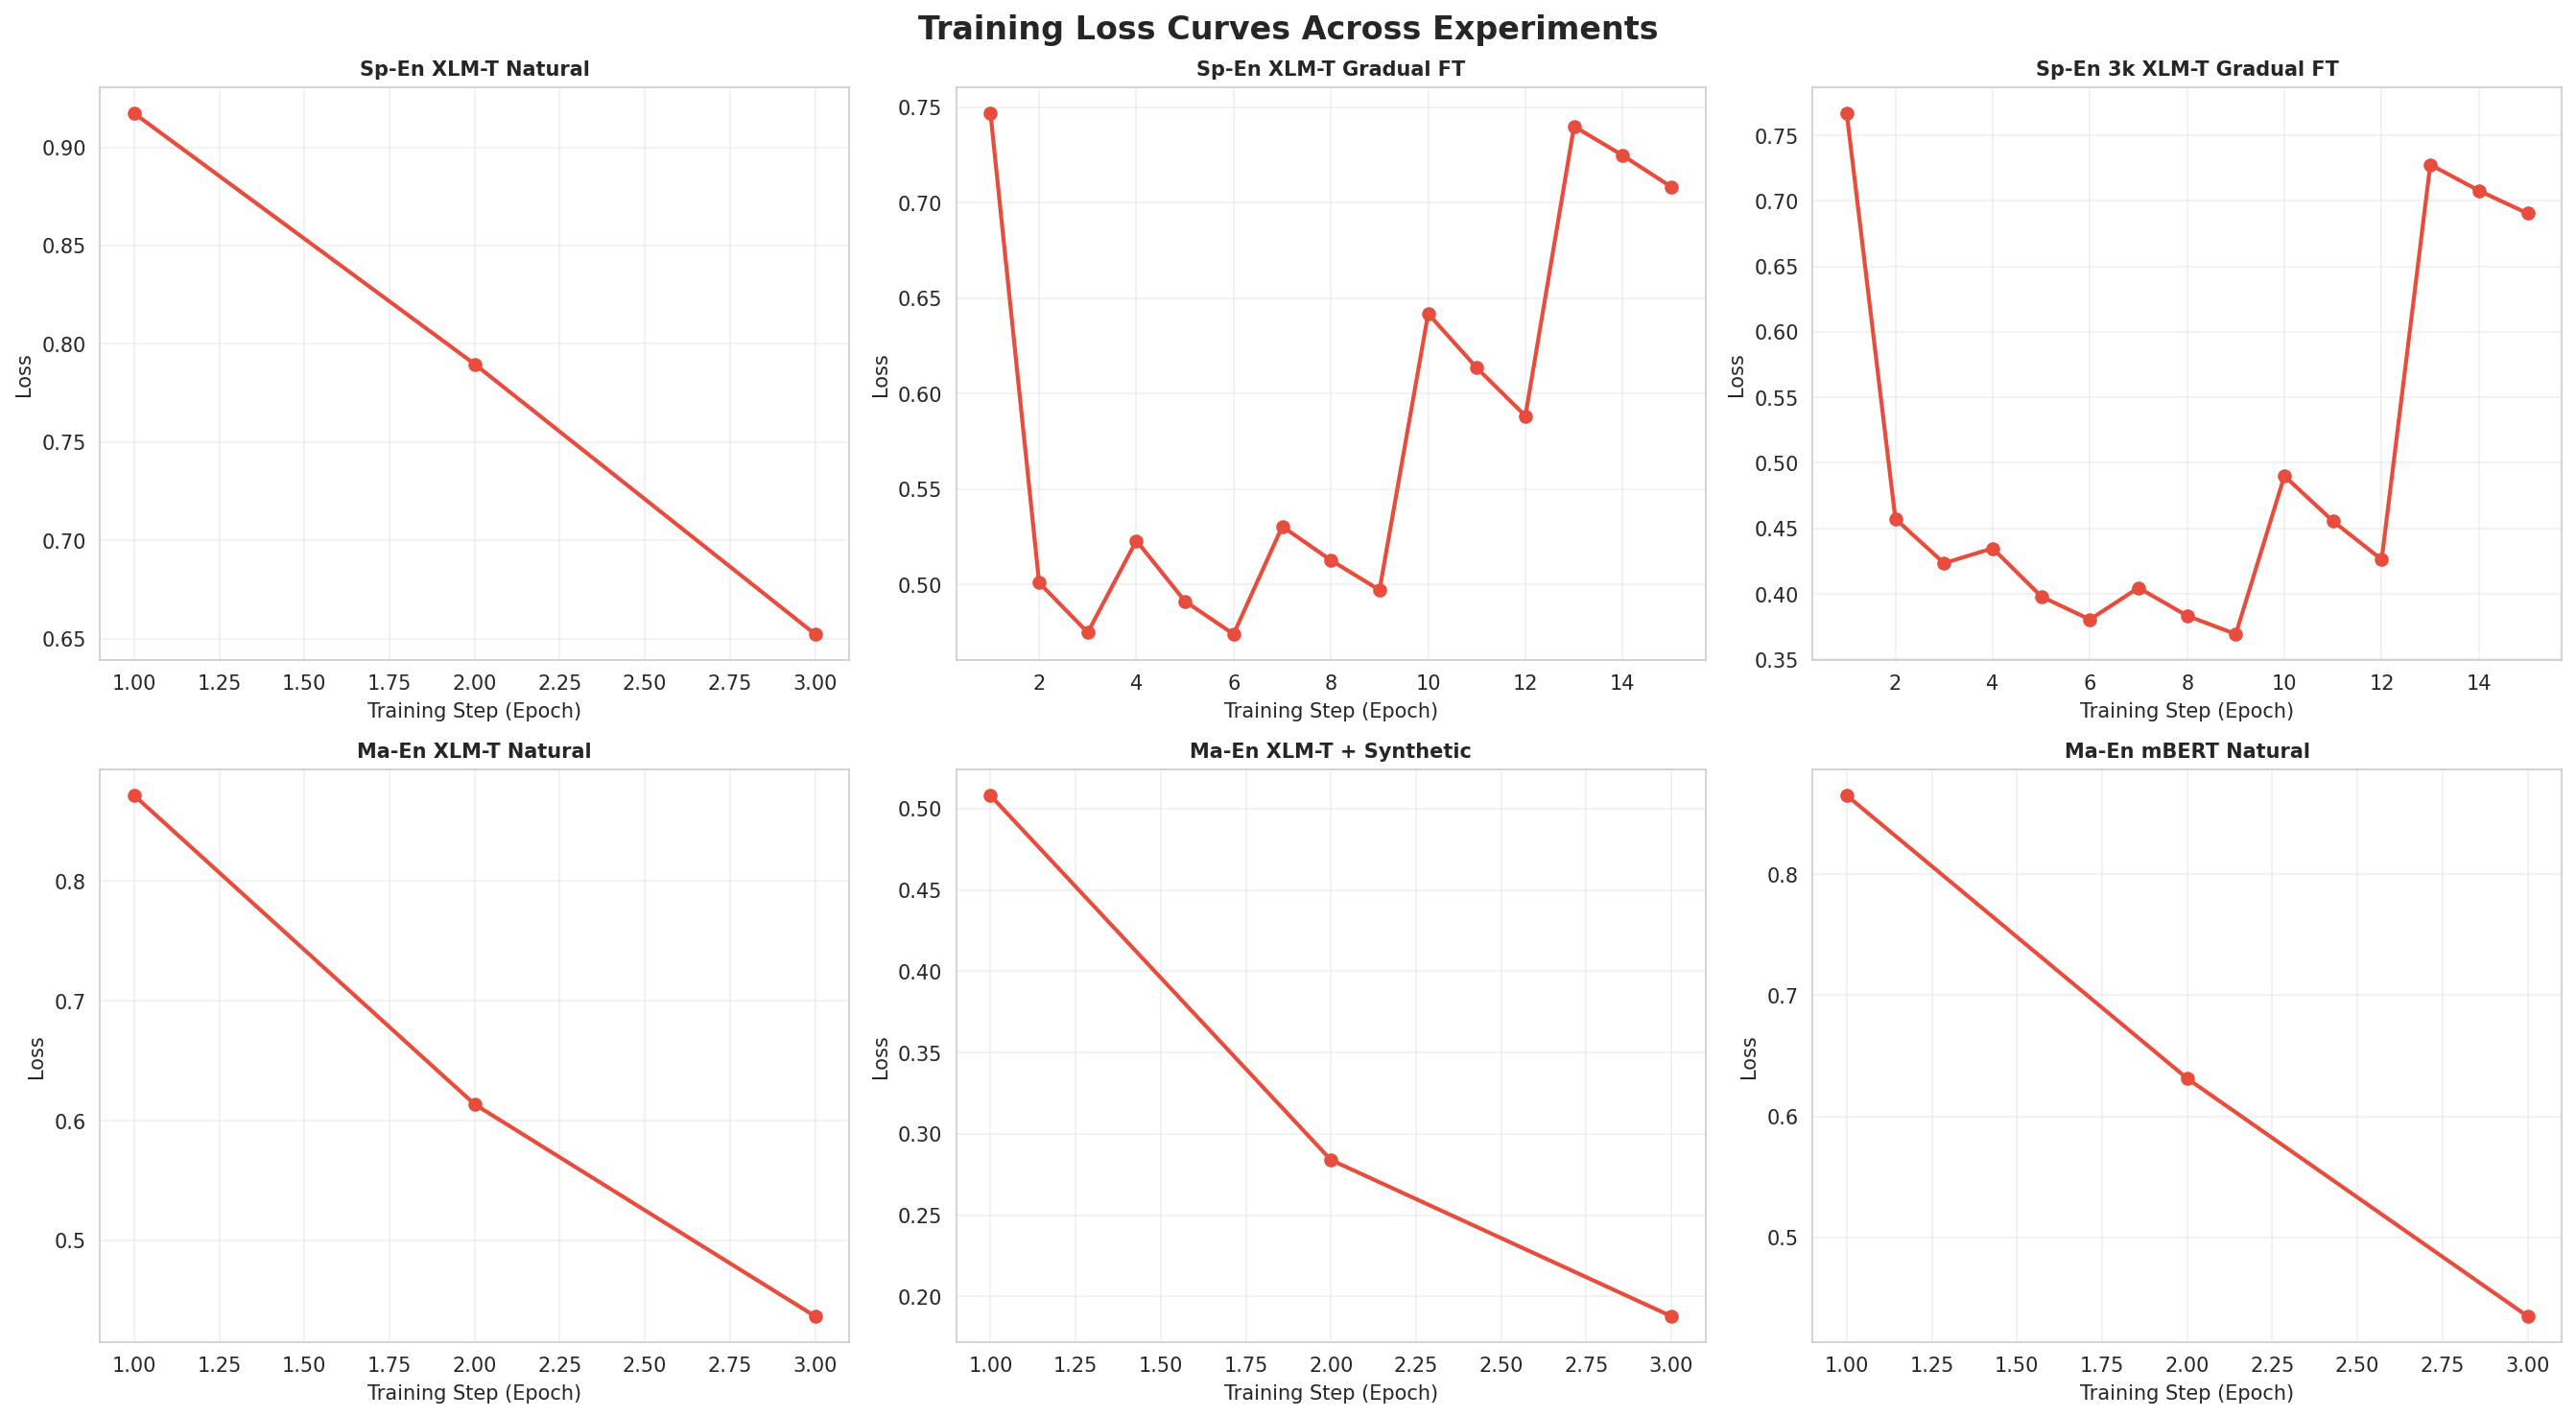

 Plot 5 saved: Training Loss Curves


In [34]:
# ─── Plot 5: Training Loss Curves ───
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training Loss Curves Across Experiments", fontsize=16, fontweight='bold')

exp_loss_plots = [
    ("sp_xlmt_natural",  "Sp-En XLM-T Natural",       axes[0,0]),
    ("sp_xlmt_gradual",  "Sp-En XLM-T Gradual FT",    axes[0,1]),
    ("sp3k_xlmt_gradual","Sp-En 3k XLM-T Gradual FT", axes[0,2]),
    ("ma_xlmt_natural",  "Ma-En XLM-T Natural",        axes[1,0]),
    ("ma_xlmt_combined", "Ma-En XLM-T + Synthetic",    axes[1,1]),
    ("ma_mbert_natural", "Ma-En mBERT Natural",         axes[1,2]),
]

for key, title, ax in exp_loss_plots:
    losses = results[key]["losses"]
    ax.plot(range(1, len(losses)+1), losses, marker='o', color='#e74c3c', linewidth=2)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Training Step (Epoch)")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plot5_training_losses.png", bbox_inches='tight')
plt.show()
print(" Plot 5 saved: Training Loss Curves")

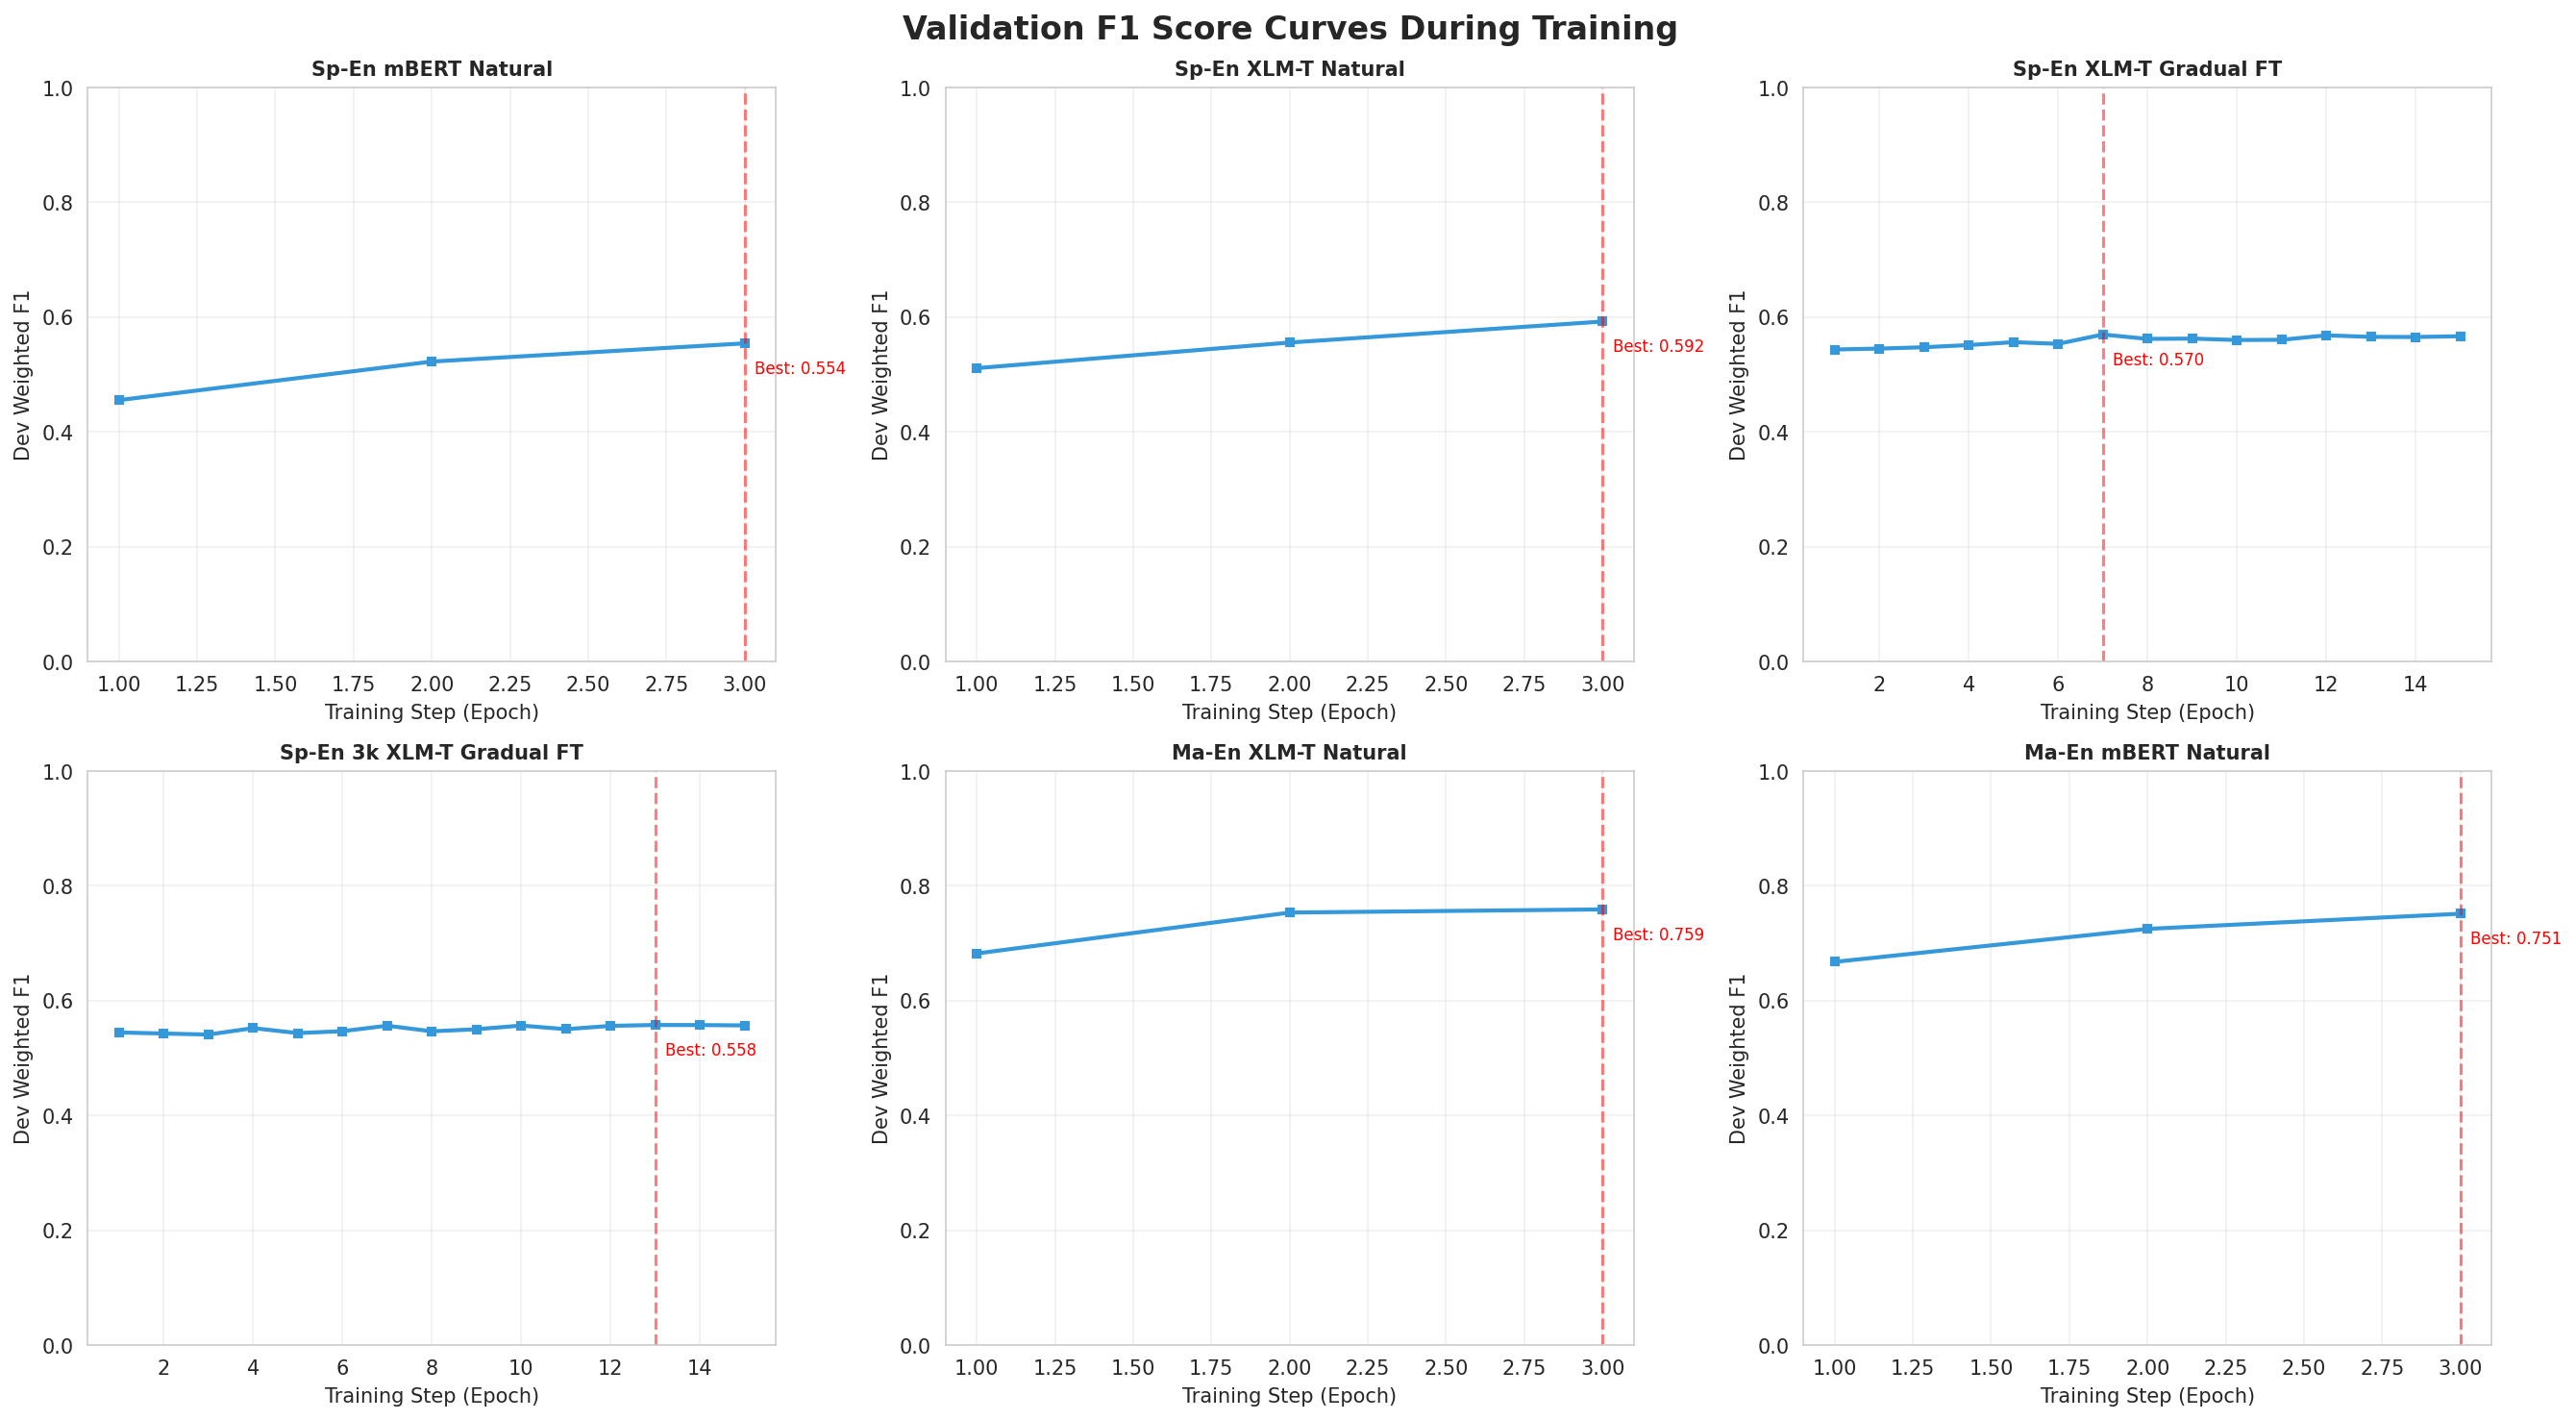

 Plot 6 saved: Dev F1 Curves


In [39]:
# ─── Plot 6: Dev F1 Curves ───
# Dynamically build from whatever results exist so far
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Validation F1 Score Curves During Training", fontsize=16, fontweight='bold')

# Only plot experiments that have been run
available = [
    ("sp_mbert_natural",   "Sp-En mBERT Natural"),
    ("sp_xlmt_natural",    "Sp-En XLM-T Natural"),
    ("sp_xlmt_gradual",    "Sp-En XLM-T Gradual FT"),
    ("sp3k_xlmt_gradual",  "Sp-En 3k XLM-T Gradual FT"),
    ("ma_xlmt_natural",    "Ma-En XLM-T Natural"),
    ("ma_mbert_natural",   "Ma-En mBERT Natural"),
]

for ax_idx, (key, title) in enumerate(available):
    ax = axes[ax_idx // 3][ax_idx % 3]
    if key not in results:
        ax.text(0.5, 0.5, f'Not run yet\n({key})',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='gray')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_visible(True)
        continue

    dev_f1s = results[key]["dev_f1s"]
    ax.plot(range(1, len(dev_f1s)+1), dev_f1s,
            marker='s', color='#3498db', linewidth=2, markersize=4)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Training Step (Epoch)")
    ax.set_ylabel("Dev Weighted F1")
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)

    # Mark best epoch
    best_epoch = dev_f1s.index(max(dev_f1s)) + 1
    best_f1    = max(dev_f1s)
    ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5)
    ax.annotate(f'Best: {best_f1:.3f}',
                xy=(best_epoch, best_f1),
                xytext=(5, -15), textcoords='offset points',
                fontsize=8, color='red')

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plot6_dev_f1_curves.png", bbox_inches='tight')
plt.show()
print(" Plot 6 saved: Dev F1 Curves")

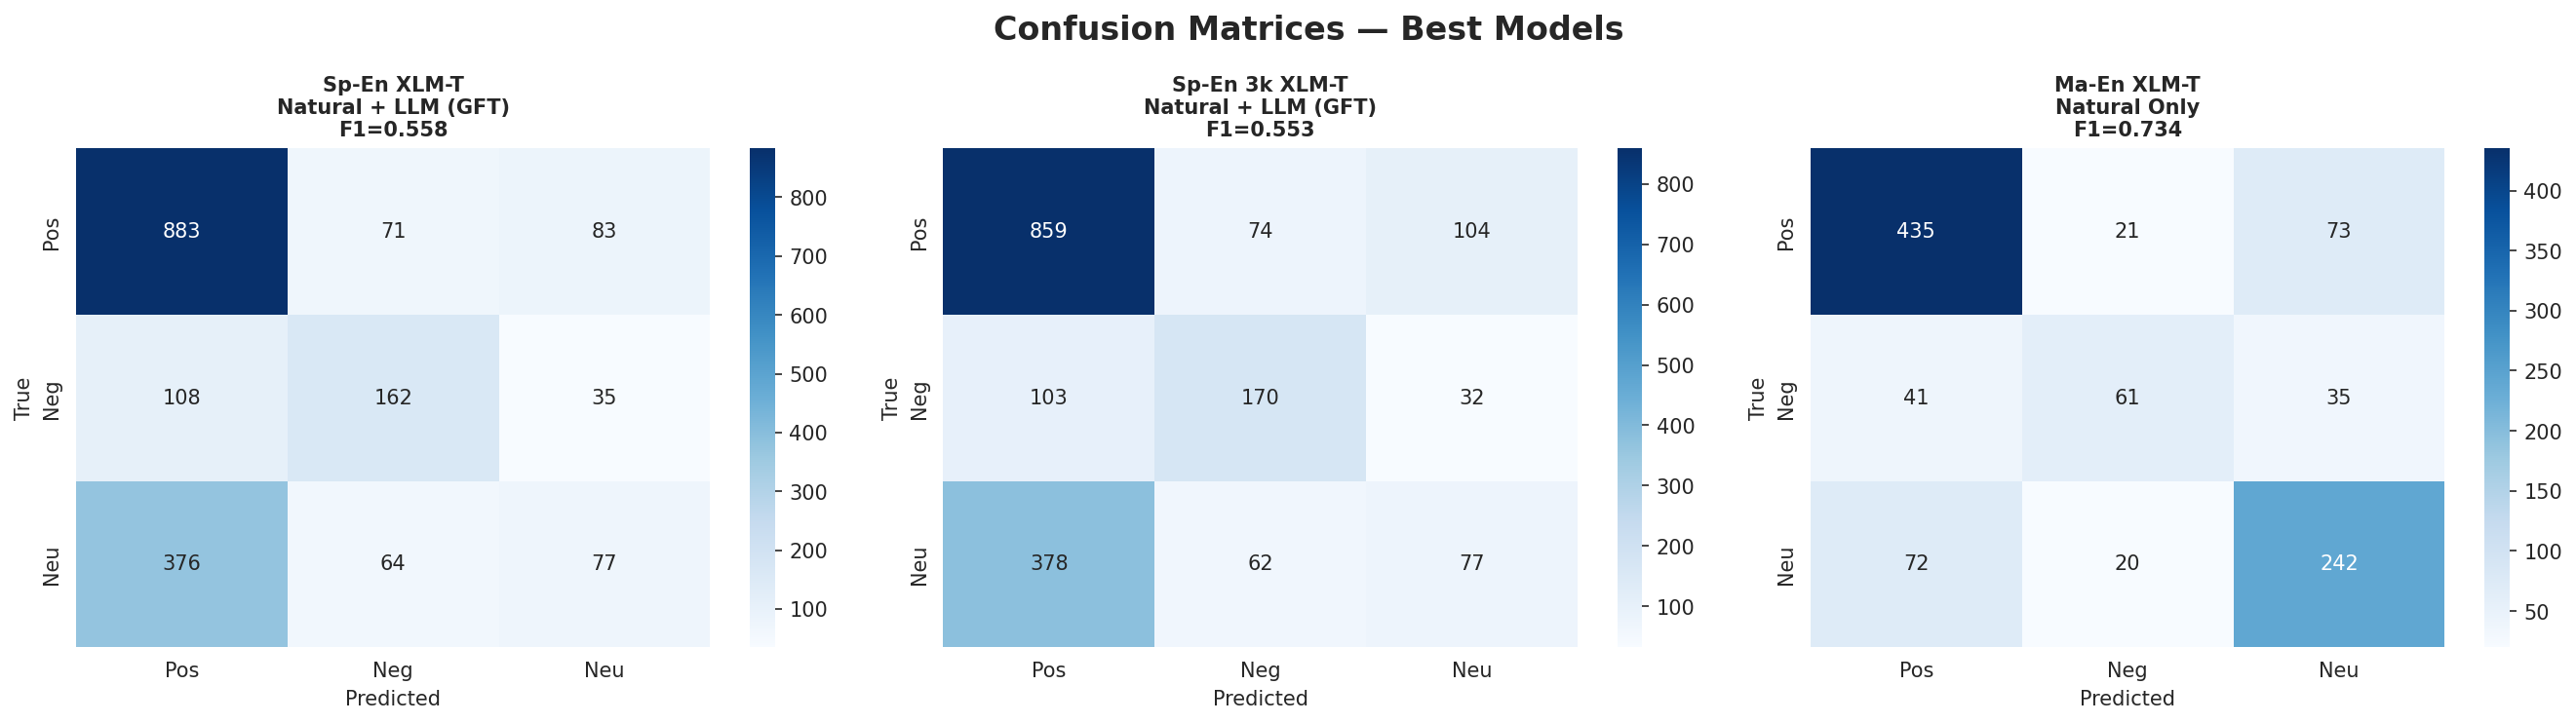

 Plot 7 saved: Confusion Matrices


In [36]:
# ─── Plot 7: Confusion Matrices for best models ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Best Models", fontsize=16, fontweight='bold')

best_models = [
    ("sp_xlmt_gradual",  "Sp-En XLM-T\nNatural + LLM (GFT)",  axes[0]),
    ("sp3k_xlmt_gradual","Sp-En 3k XLM-T\nNatural + LLM (GFT)", axes[1]),
    ("ma_xlmt_natural",  "Ma-En XLM-T\nNatural Only",          axes[2]),
]

for key, title, ax in best_models:
    cm = confusion_matrix(results[key]["labels"], results[key]["preds"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Pos", "Neg", "Neu"],
                yticklabels=["Pos", "Neg", "Neu"])
    ax.set_title(f"{title}\nF1={results[key]['f1']:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plot7_confusion_matrices.png", bbox_inches='tight')
plt.show()
print(" Plot 7 saved: Confusion Matrices")

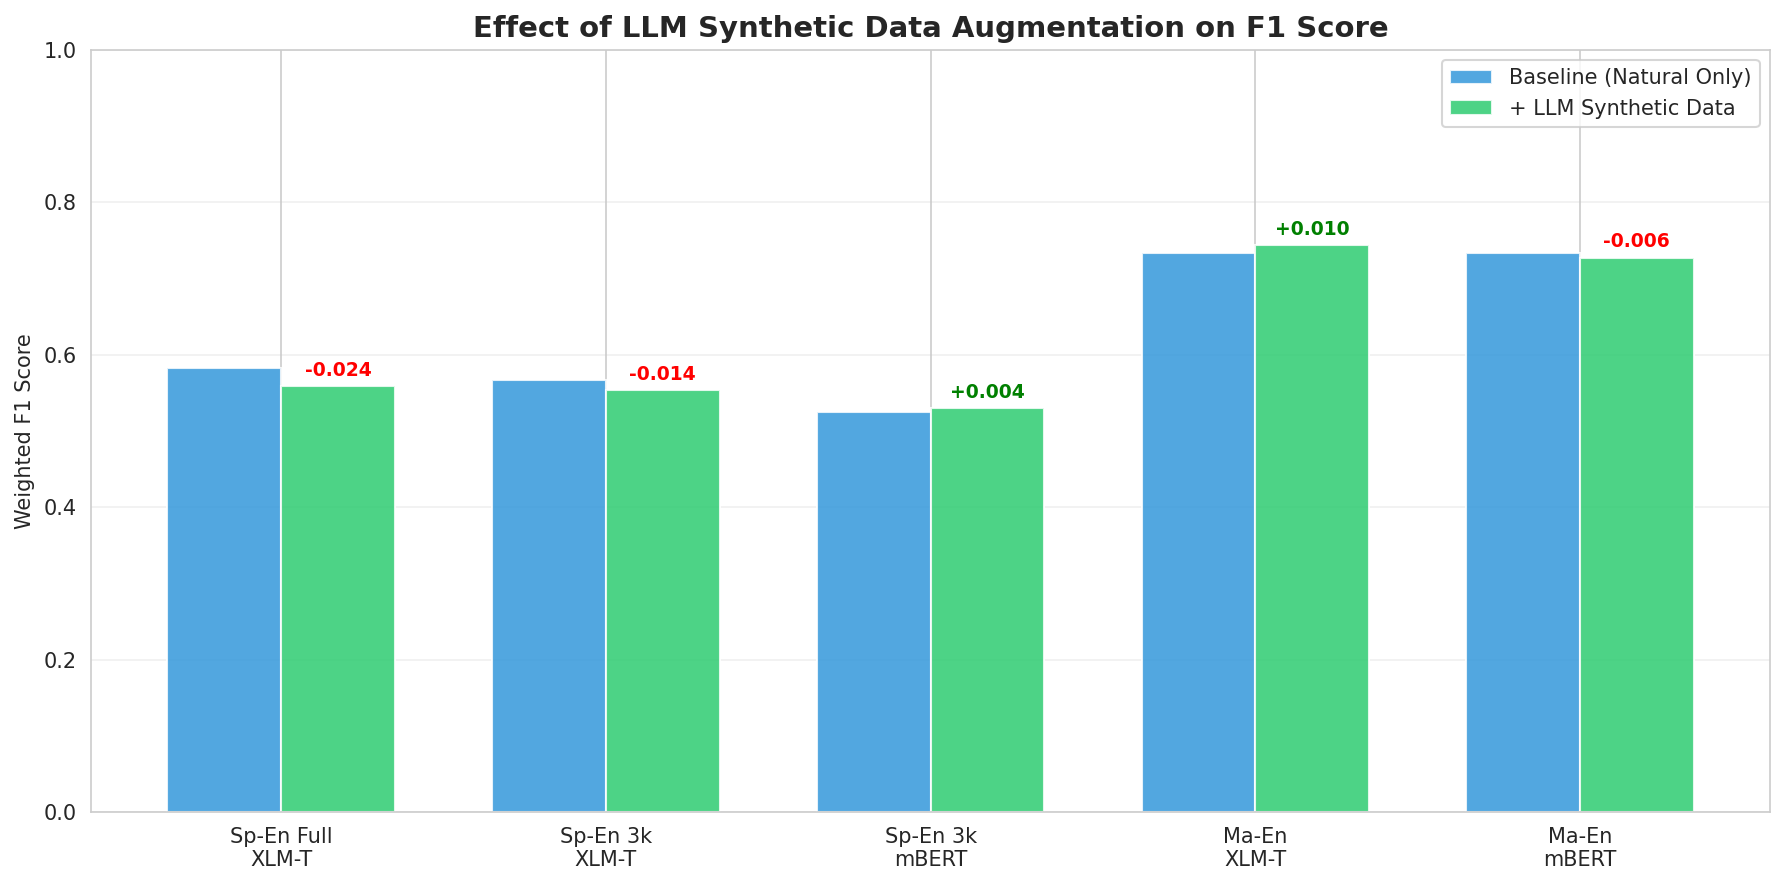

 Plot 8 saved: Augmentation Effect


In [37]:
# ─── Plot 8: F1 Improvement from Synthetic Data Augmentation ───
fig, ax = plt.subplots(figsize=(12, 6))

aug_comparison = [
    ("Sp-En Full\nXLM-T",  results["sp_xlmt_natural"]["f1"],   results["sp_xlmt_gradual"]["f1"]),
    ("Sp-En 3k\nXLM-T",   results["sp3k_xlmt_natural"]["f1"],  results["sp3k_xlmt_gradual"]["f1"]),
    ("Sp-En 3k\nmBERT",   results["sp3k_mbert_natural"]["f1"], results["sp3k_mbert_gradual"]["f1"]),
    ("Ma-En\nXLM-T",      results["ma_xlmt_natural"]["f1"],    results["ma_xlmt_combined"]["f1"]),
    ("Ma-En\nmBERT",      results["ma_mbert_natural"]["f1"],   results["ma_mbert_combined"]["f1"]),
]

labels_bar = [x[0] for x in aug_comparison]
baseline   = [x[1] for x in aug_comparison]
augmented  = [x[2] for x in aug_comparison]
x = np.arange(len(labels_bar))
width = 0.35

bars1 = ax.bar(x - width/2, baseline,  width, label="Baseline (Natural Only)", color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, augmented, width, label="+ LLM Synthetic Data",    color="#2ecc71", alpha=0.85)

for i, (b, a) in enumerate(zip(baseline, augmented)):
    diff = a - b
    color = 'green' if diff >= 0 else 'red'
    ax.annotate(f"{diff:+.3f}",
                xy=(x[i] + width/2, a),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_bar, fontsize=10)
ax.set_ylabel("Weighted F1 Score")
ax.set_title("Effect of LLM Synthetic Data Augmentation on F1 Score",
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/plot8_augmentation_effect.png", bbox_inches='tight')
plt.show()
print(" Plot 8 saved: Augmentation Effect")

---
# SECTION 12: Save All Results
---
Save the full results dictionary as JSON for reproducibility logging,  
and print a final summary of all plots and files saved.

In [38]:
# ─── Save experiment log (JSON) ───
log = {}
for key, val in results.items():
    log[key] = {
        "paper_f1":      val["paper_f1"],
        "reproduced_f1": round(val["f1"], 4),
        "difference":    round(val["f1"] - val["paper_f1"], 4),
        "train_losses":  [round(l, 4) for l in val["losses"]],
        "dev_f1s":       [round(f, 4) for f in val["dev_f1s"]],
    }

with open(f"{PLOT_DIR}/experiment_log.json", "w") as f:
    json.dump(log, f, indent=2)

print(" Experiment log saved: plots/experiment_log.json")

# ─── Final Summary ───
print("\n" + "="*65)
print(" FINAL SUMMARY: All Experiments Complete")
print("="*65)
print(f"{'Experiment':<30} {'Paper F1':>10} {'Our F1':>10} {'Diff':>10}")
print("-"*65)
for key, val in log.items():
    print(f"{key:<30} {val['paper_f1']:>10.3f} {val['reproduced_f1']:>10.3f} {val['difference']:>+10.3f}")

print("\n Saved files in ./plots/:")
for f in sorted(os.listdir(PLOT_DIR)):
    print(f"    {f}")

 Experiment log saved: plots/experiment_log.json

 FINAL SUMMARY: All Experiments Complete
Experiment                       Paper F1     Our F1       Diff
-----------------------------------------------------------------
sp_mbert_natural                    0.564      0.544     -0.019
sp_xlmt_natural                     0.588      0.582     -0.006
sp_xlmt_syn_only                    0.544      0.531     -0.013
sp_xlmt_gradual                     0.603      0.558     -0.045
sp_xlmt_random                      0.563      0.581     +0.018
sp3k_xlmt_natural                   0.547      0.567     +0.020
sp3k_xlmt_gradual                   0.598      0.553     -0.045
sp3k_mbert_natural                  0.487      0.525     +0.038
sp3k_mbert_gradual                  0.526      0.529     +0.003
ma_mbert_natural                    0.750      0.733     -0.017
ma_xlmt_natural                     0.843      0.734     -0.109
ma_xlmt_combined                    0.763      0.744     -0.019
ma_mbert_co